# Boilerplate

In [1]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

CHOICES = ["A", "B", "C", "D"]


def load_data(path, key="forget_mcqa_prob"):
    with open(path, "r") as f:
        data = json.load(f)

    values = data[key]["value_by_index"]

    y_true = []
    y_pred = []
    probs = []

    for k in values:
        item = values[k]

        y_true.append(item["label"].strip())
        y_pred.append(item["generated choice"].strip())
        probs.append(item["prob"])

    probs = np.array(probs)

    return y_true, y_pred, probs


# -----------------------
# Accuracy + F1
# -----------------------

def compute_accuracy_f1(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


# -----------------------
# Brier score (multiclass)
# -----------------------

def compute_brier(y_true, probs):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    one_hot = np.zeros_like(probs)
    one_hot[np.arange(len(y_true_idx)), y_true_idx] = 1

    brier = np.mean(np.sum((probs - one_hot) ** 2, axis=1))

    return brier


# -----------------------
# ECE / MCE
# -----------------------

def compute_ece_mce(y_true, probs, n_bins=10):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    conf = np.max(probs, axis=1)
    pred = np.argmax(probs, axis=1)

    correct = (pred == y_true_idx).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    mce = 0.0

    for i in range(n_bins):

        mask = (conf >= bins[i]) & (conf < bins[i + 1])

        if np.sum(mask) == 0:
            continue

        acc_bin = np.mean(correct[mask])
        conf_bin = np.mean(conf[mask])

        gap = abs(acc_bin - conf_bin)

        ece += np.sum(mask) / len(conf) * gap
        mce = max(mce, gap)

    return ece, mce

# -----------------------
# Reliability Diagram
# -----------------------


def plot_reliability_diagram(y_true, probs, n_bins=10, title="", key=""):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    conf = np.max(probs, axis=1)
    pred = np.argmax(probs, axis=1)

    correct = (pred == y_true_idx).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_count = []

    for i in range(n_bins):

        mask = (conf >= bins[i]) & (conf < bins[i + 1])

        if np.sum(mask) == 0:
            bin_acc.append(0)
            bin_conf.append(0)
            bin_count.append(0)
            continue

        bin_acc.append(np.mean(correct[mask]))
        bin_conf.append(np.mean(conf[mask]))
        bin_count.append(np.sum(mask))

    bin_acc = np.array(bin_acc)
    bin_conf = np.array(bin_conf)
    bin_count = np.array(bin_count)

    # ----- plot -----

    # fig = plt.figure()

    # bars = accuracy
    plt.bar(
        np.linspace(0.05, 0.95, n_bins),
        bin_acc,
        width=0.08,
        alpha=0.6,
        label="Accuracy",
    )

    # # confidence line
    # plt.plot(
    #     np.linspace(0.05, 0.95, n_bins),
    #     bin_conf,
    #     marker="o",
    #     label="Confidence",
    # )

    # perfect calibration
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - {key}", fontsize=20)

    plt.legend()

    # return fig
    # plt.savefig(f"saves/eval/plots/phi-1_5/{title}_{key}_reliability_diagram.png", dpi=300, bbox_inches="tight")
    # plt.show()
    


# -----------------------
# MAIN
# -----------------------

def print_metrics_and_plot(path, title, subfig_nrows=None, subfig_ncols=None, subfig_pos=None, n_bins=10):
    
    ret_values = []
    
    forget_percentage = int(title.split()[-1].replace("%",""))
    retain_percentage = 100 - forget_percentage
    title = " ".join(title.split()[:-1])
    
    for i, (key, key_title) in enumerate([
        ("retain_mcqa_prob", f"Retain {retain_percentage:2.0f}%"),
        ("forget_mcqa_prob", f"Forget {forget_percentage:2.0f} %") 
        ]):
        print(f"--- {key_title} ---")
        y_true, y_pred, probs = load_data(path, key=key)

        acc, f1 = compute_accuracy_f1(y_true, y_pred)
        brier = compute_brier(y_true, probs)
        ece, mce = compute_ece_mce(y_true, probs, n_bins)

        print("Accuracy:", acc)
        print("F1:", f1)
        print("Brier:", brier)
        print("ECE:", ece)
        print("MCE:", mce)
        
        if subfig_nrows is not None and subfig_ncols is not None and subfig_pos is not None:
            plt.subplot(subfig_nrows, subfig_ncols, subfig_pos+i)
        plot_reliability_diagram(y_true, probs, n_bins=10, title=title, key=key_title)
        
        ret_values.append({"key": key, "accuracy": acc, "f1": f1, "brier": brier, "ece": ece, "mce": mce})
        
    return ret_values

###############################################################################

# Phi

## Forget 10%

In [3]:
# model_name = "Llama-3.1-8B-Instruct"
model_name = "phi-1_5"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [    
    ("relu_{model_name}_full_retain90", "Full Finetuned 10%"),
    ("relu_{model_name}_pretrained_retain90", "Pretrained 10%"),
    ("relu_{model_name}_retain90_batch1", "Retained 10%"),
]

unlearn_tasks = [
    # ("tofu_{model_name}_forget01_GradAscent", "checkpoint-2", "GradAscent 1%"),
    # ("tofu_{model_name}_forget01_GradAscent", "checkpoint-5", "GradAscent 1%"),
    # ("tofu_{model_name}_forget01_GradAscent", "checkpoint-7", "GradAscent 1%"),
    # ("tofu_{model_name}_forget01_GradAscent", "checkpoint-10", "GradAscent 1%"),
    
    # ("tofu_{model_name}_forget01_GradDiff", "checkpoint-2", "GradDiff 1%"),
    # ("tofu_{model_name}_forget01_GradDiff", "checkpoint-5", "GradDiff 1%"),
    # ("tofu_{model_name}_forget01_GradDiff", "checkpoint-7", "GradDiff 1%"),
    # ("tofu_{model_name}_forget01_GradDiff", "checkpoint-10", "GradDiff 1%"),
    
    # ("tofu_{model_name}_forget01_NPO", "checkpoint-2", "NPO 1%"),
    # ("tofu_{model_name}_forget01_NPO", "checkpoint-5", "NPO 1%"),
    # ("tofu_{model_name}_forget01_NPO", "checkpoint-7", "NPO 1%"),
    # ("tofu_{model_name}_forget01_NPO", "checkpoint-10", "NPO 1%"),
    
    # ("tofu_{model_name}_forget01_DPO", "checkpoint-2", "DPO 1%"),
    # ("tofu_{model_name}_forget01_DPO", "checkpoint-5", "DPO 1%"),
    # ("tofu_{model_name}_forget01_DPO", "checkpoint-7", "DPO 1%"),
    # ("tofu_{model_name}_forget01_DPO", "checkpoint-10", "DPO 1%"),
]

results = []

for task, task_name in tasks:
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e

for task, checkpoint, method in unlearn_tasks:
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task} | {checkpoint} ===")
        metrics = print_metrics_and_plot(unlearn_path_template.format(task_name=task, checkpoint=checkpoint), title=method)
        for m in metrics:
            results.append({"task": task, "checkpoint": checkpoint, **m})
    except Exception as e:
        print(f"Error processing {task}|{checkpoint}: {e}")
        raise e
    

df = pd.DataFrame(results)
# store all the results in a JSON file
with open("saves/eval/calibration_results_phi-1_5_forget10.json", "w") as f:
    json.dump(results, f, indent=4)


=== relu_phi-1_5_full_retain90 ===
--- Forget 10 % ---
Accuracy: 0.6516290726817042
F1: 0.6503700028183328
Brier: 0.5390729436817128
ECE: 0.2275017780767646
MCE: 0.8647355735301971
Error processing relu_phi-1_5_full_retain90: Number of rows must be a positive integer, not None


ValueError: Number of rows must be a positive integer, not None

<Figure size 640x480 with 0 Axes>

## Forget 5%

=== relu_phi-1_5_full_retain95 ===
--- Forget  5 % ---
Accuracy: 0.655
F1: 0.6532694670864273
Brier: 0.5424468583509109
ECE: 0.2564555148780346
MCE: 0.9268176555633545


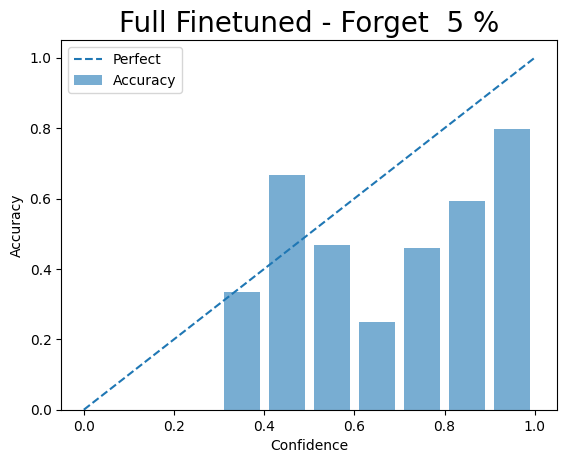

--- Retain 95% ---
Accuracy: 0.6475388260068439
F1: 0.6498859602768794
Brier: 0.5562457356043127
ECE: 0.22239356340311428
MCE: 0.573317094095822


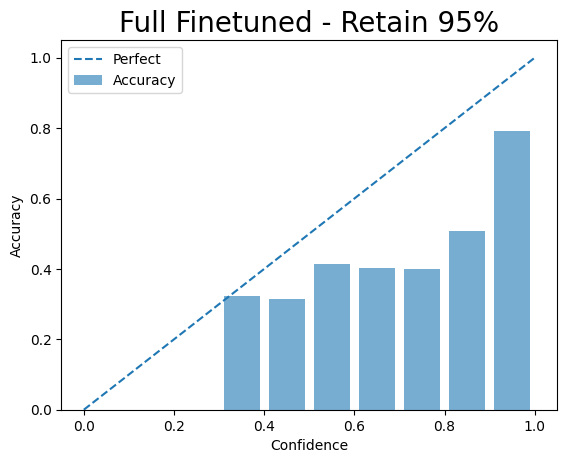

=== relu_phi-1_5_pretrained_retain95 ===
--- Forget  5 % ---
Accuracy: 0.305
F1: 0.14865862663056856
Brier: 1.0800995983786255
ECE: 0.4892969778180124
MCE: 0.9939049184322357


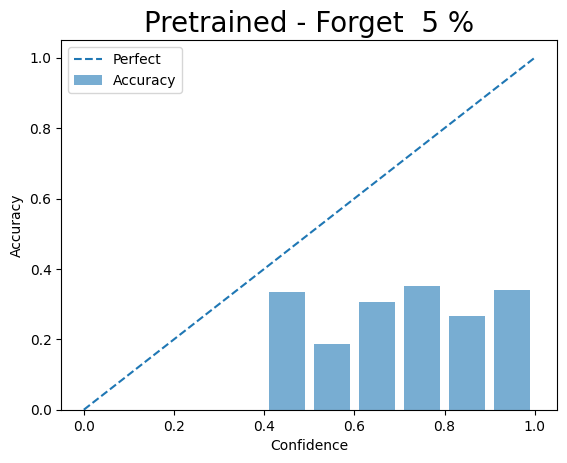

--- Retain 95% ---
Accuracy: 0.2619110292182153
F1: 0.14566499836841482
Brier: 1.1827777060669922
ECE: 0.5358233093179882
MCE: 0.8403268106204947


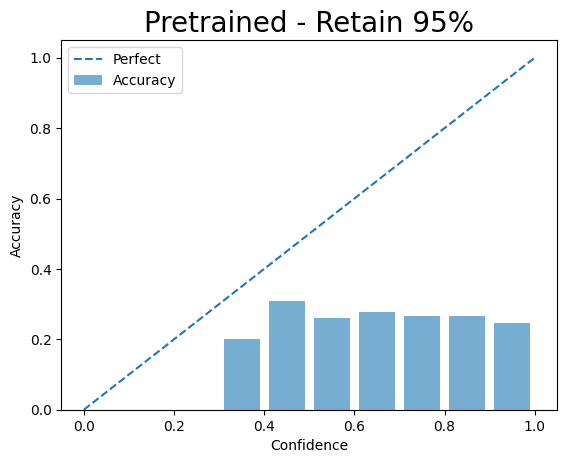

=== relu_phi-1_5_retain95 ===
--- Forget  5 % ---
Accuracy: 0.655
F1: 0.6532694670864273
Brier: 0.5424468583509109
ECE: 0.2564555148780346
MCE: 0.9268176555633545


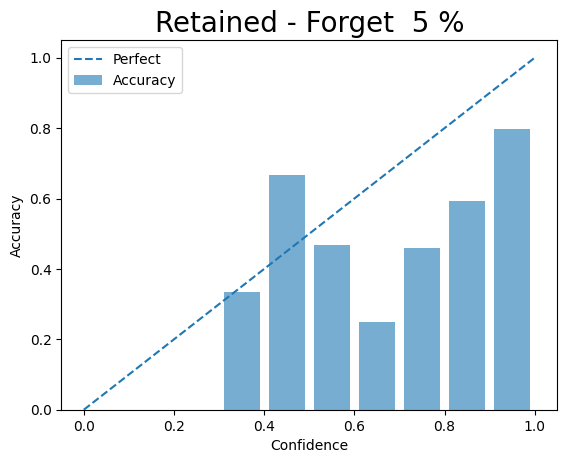

--- Retain 95% ---
Accuracy: 0.6475388260068439
F1: 0.6498859602768794
Brier: 0.5562457356043127
ECE: 0.22239356340311428
MCE: 0.573317094095822


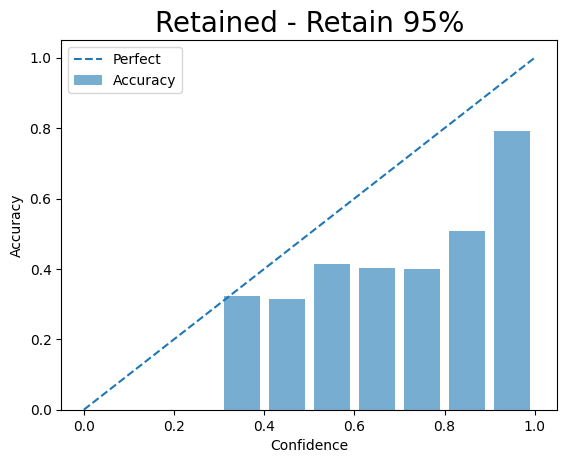

In [5]:
model_name = "phi-1_5"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [    
    ("relu_{model_name}_full_retain95", "Full Finetuned 5%"),
    ("relu_{model_name}_pretrained_retain95", "Pretrained 5%"),
    ("relu_{model_name}_retain95", "Retained 5%"),
]

unlearn_tasks = [
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-2", "GradAscent 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-5", "GradAscent 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-7", "GradAscent 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-10", "GradAscent 1%"),
    
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-2", "GradDiff 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-5", "GradDiff 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-7", "GradDiff 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-10", "GradDiff 1%"),
    
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-2", "NPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-5", "NPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-7", "NPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-10", "NPO 1%"),
    
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-2", "DPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-5", "DPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-7", "DPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-10", "DPO 1%"),
]

results = []

for task, task_name in tasks:
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e

for task, checkpoint, method in unlearn_tasks:
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task} | {checkpoint} ===")
        metrics = print_metrics_and_plot(unlearn_path_template.format(task_name=task, checkpoint=checkpoint), title=method)
        for m in metrics:
            results.append({"task": task, "checkpoint": checkpoint, **m})
    except Exception as e:
        print(f"Error processing {task}|{checkpoint}: {e}")
        raise e
    

df = pd.DataFrame(results)
# store all the results in a JSON file
with open("saves/eval/calibration_results-phi_1_5-forget05.json", "w") as f:
    json.dump(results, f, indent=4)


## Forget 1%

=== relu_phi-1_5_full_retain99 ===
--- Forget  1 % ---
Accuracy: 0.65
F1: 0.6169825380851047
Brier: 0.5468474112324146
ECE: 0.2607791535556317
MCE: 0.9798460602760315


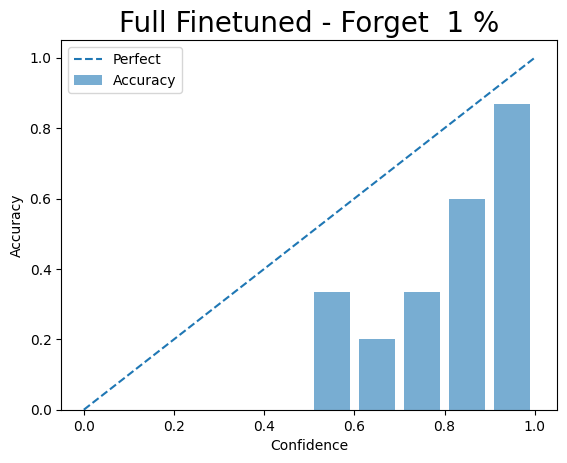

--- Retain 99% ---
Accuracy: 0.6377873200303107
F1: 0.6397767090680879
Brier: 0.5704943960173952
ECE: 0.2282871982761632
MCE: 0.506883276136298


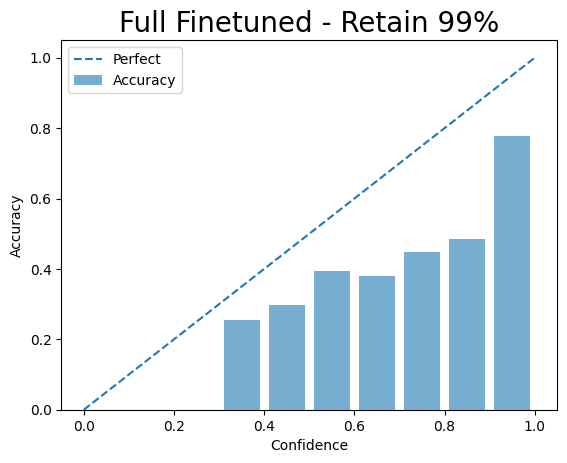

=== relu_phi-1_5_pretrained_retain99 ===
--- Forget  1 % ---
Accuracy: 0.425
F1: 0.19930069930069932
Brier: 0.8358662758025744
ECE: 0.4310769334435464
MCE: 0.9545520544052124


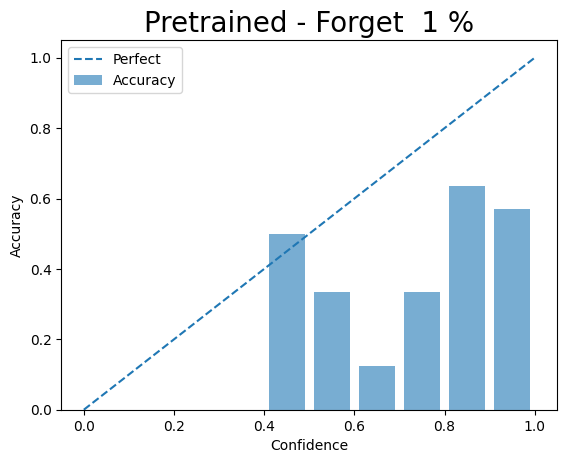

--- Retain 99% ---
Accuracy: 0.2578934074261177
F1: 0.14193832207331591
Brier: 1.1844258660021563
ECE: 0.5374412350008421
MCE: 0.7604309843510997


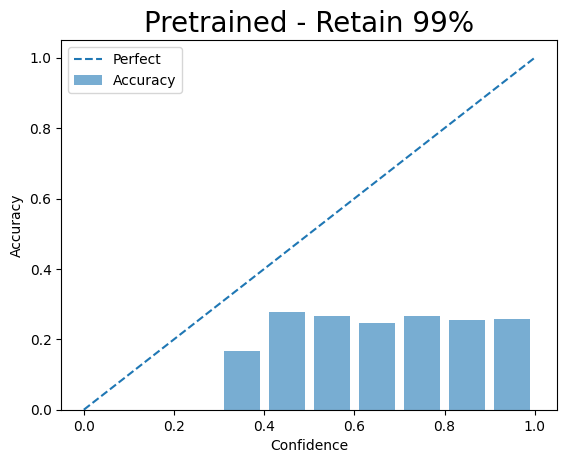

=== relu_phi-1_5_retain99 ===
--- Forget  1 % ---
Accuracy: 0.65
F1: 0.6169825380851047
Brier: 0.5468474112324146
ECE: 0.2607791535556317
MCE: 0.9798460602760315


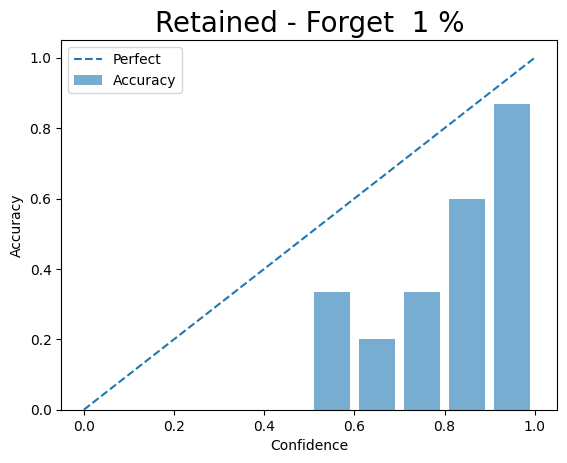

--- Retain 99% ---
Accuracy: 0.6377873200303107
F1: 0.6397767090680879
Brier: 0.5704943960173952
ECE: 0.2282871982761632
MCE: 0.506883276136298


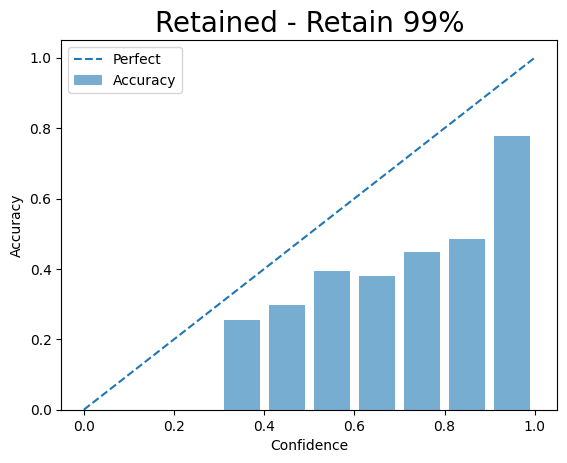

In [7]:
model_name = "phi-1_5"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [    
    ("relu_{model_name}_full_retain99", "Full Finetuned 1%"),
    ("relu_{model_name}_pretrained_retain99", "Pretrained 1%"),
    ("relu_{model_name}_retain99", "Retained 1%"),
]

unlearn_tasks = [
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-2", "GradAscent 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-5", "GradAscent 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-7", "GradAscent 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradAscent", "checkpoint-10", "GradAscent 1%"),
    
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-2", "GradDiff 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-5", "GradDiff 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-7", "GradDiff 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_GradDiff", "checkpoint-10", "GradDiff 1%"),
    
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-2", "NPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-5", "NPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-7", "NPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_NPO", "checkpoint-10", "NPO 1%"),
    
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-2", "DPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-5", "DPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-7", "DPO 1%"),
    # ("tofu_Llama-3.1-8B-Instruct_forget01_DPO", "checkpoint-10", "DPO 1%"),
]

results = []

for task, task_name in tasks:
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e

for task, checkpoint, method in unlearn_tasks:
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task} | {checkpoint} ===")
        metrics = print_metrics_and_plot(unlearn_path_template.format(task_name=task, checkpoint=checkpoint), title=method)
        for m in metrics:
            results.append({"task": task, "checkpoint": checkpoint, **m})
    except Exception as e:
        print(f"Error processing {task}|{checkpoint}: {e}")
        raise e
    

df = pd.DataFrame(results)
# store all the results in a JSON file
with open("saves/eval/calibration_results-phi_1_5-forget01.json", "w") as f:
    json.dump(results, f, indent=4)


## Reference models at all forget sizes

=== ('relu_phi-1_5_pretrained_retain90_batch32', 0) ===
--- Retain 90% ---
Accuracy: 0.6477777777777778
F1: 0.6487165070318534
Brier: 0.4386004047298829
ECE: 0.05768121001621088
MCE: 0.265604704618454
--- Forget 10 % ---
Accuracy: 0.6942355889724311
F1: 0.6899743660333755
Brier: 0.41066709387252665
ECE: 0.13312126894044993
MCE: 0.7424337863922119
=== ('relu_phi-1_5_pretrained_retain95_batch32', 1) ===
--- Retain 95% ---
Accuracy: 0.6651750460647539
F1: 0.6658356809919135
Brier: 0.424270926834889
ECE: 0.05046100091168551
MCE: 0.2575662136077881
--- Forget  5 % ---
Accuracy: 0.665
F1: 0.658181858608551
Brier: 0.4367075130933749
ECE: 0.16143230244517318
MCE: 0.7693047523498535
=== ('relu_phi-1_5_pretrained_retain99_batch32', 2) ===
--- Retain 99% ---
Accuracy: 0.6617832786057085
F1: 0.6635871048430669
Brier: 0.43025329194506123
ECE: 0.04278106739437319
MCE: 0.2575662136077881
--- Forget  1 % ---
Accuracy: 0.55
F1: 0.5326797385620915
Brier: 0.4246163694601021
ECE: 0.30695992186665544
MCE: 

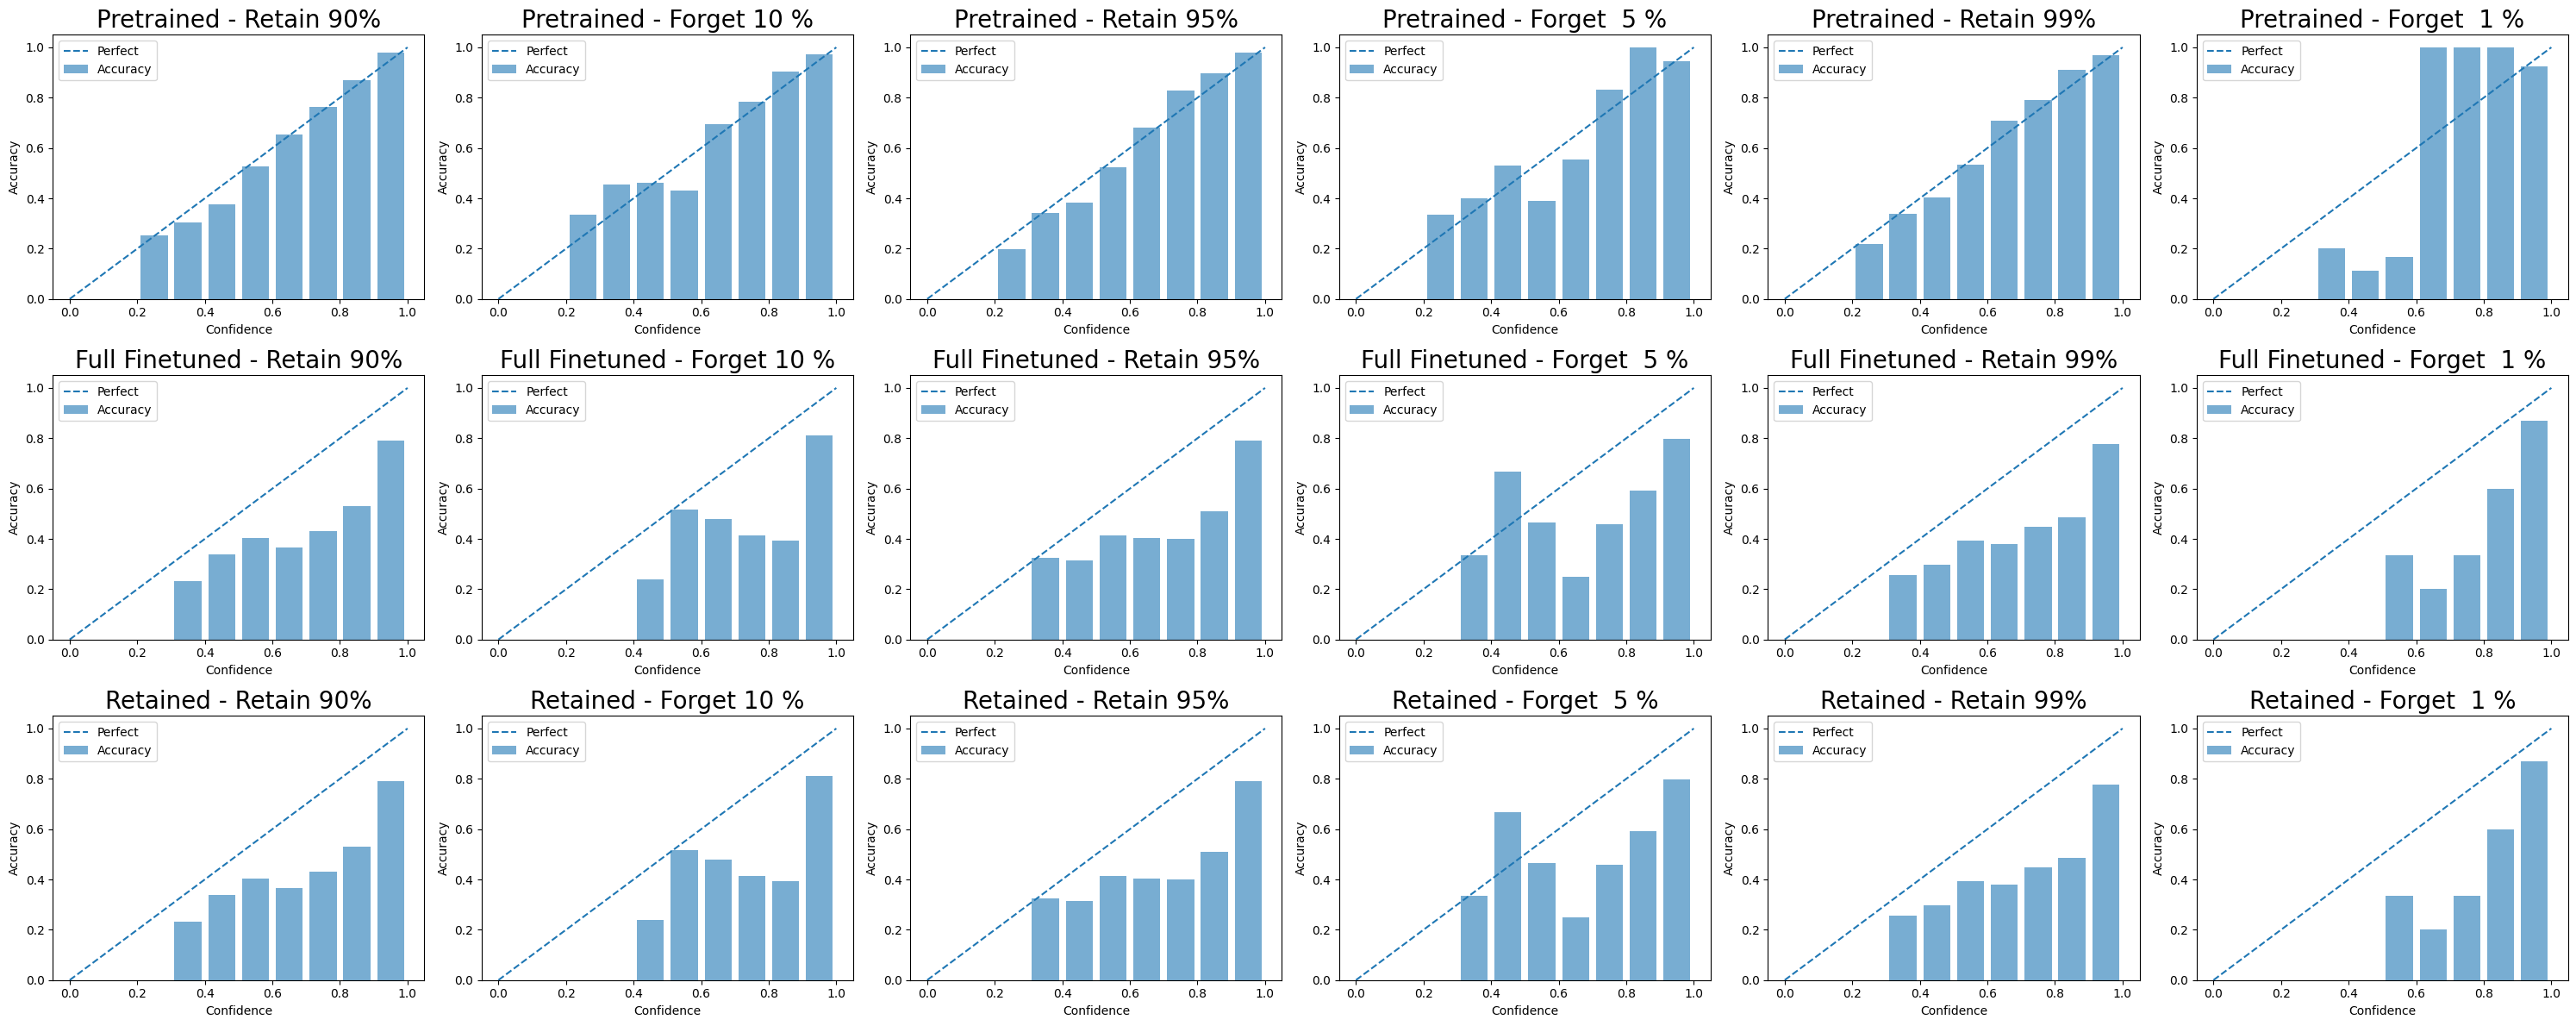

In [6]:
model_name = "phi-1_5"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [
    ("relu_{model_name}_pretrained_retain90_batch32", "Pretrained 10%"),
    ("relu_{model_name}_pretrained_retain95_batch32", "Pretrained 5%"),
    ("relu_{model_name}_pretrained_retain99_batch32", "Pretrained 1%"),

    ("relu_{model_name}_full_retain90", "Full Finetuned 10%"),
    ("relu_{model_name}_full_retain95", "Full Finetuned 5%"),
    ("relu_{model_name}_full_retain99", "Full Finetuned 1%"),


    ("relu_{model_name}_retain90_batch1", "Retained 10%"),
    ("relu_{model_name}_retain95_batch1", "Retained 5%"),
    ("relu_{model_name}_retain99_batch1", "Retained 1%"),
]

nrows = 3
ncols = 6
plt.figure(figsize=(ncols*5, nrows*4))

results = []

for i, (task, task_name) in enumerate(tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name, subfig_nrows=3, subfig_ncols=6, subfig_pos=i*2+1)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e
    
plt.tight_layout()
df = pd.DataFrame(results)
# store all the results in a JSON file
with open("saves/eval/calibration_results-phi_1_5-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)


# OLD Llama reports

## Llama 3 1B

=== ('old_llama_evals/relu_Llama-3.2-1B-Instruct_pretrained_retain90', 0) ===
--- Retain 90% ---
Accuracy: 0.26555555555555554
F1: 0.14609762849888297
Brier: 1.143560509118443
ECE: 0.5188114721576373
MCE: 0.7382622822826984
--- Forget 10 % ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.5106768918067291
MCE: 0.8245976030826568
=== ('old_llama_evals/relu_Llama-3.2-1B-Instruct_pretrained_retain95', 1) ===
--- Retain 95% ---
Accuracy: 0.26033166622795473
F1: 0.14194567759314078
Brier: 1.1517394225319888
ECE: 0.5245812726463259
MCE: 0.7208583869096887
--- Forget  5 % ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.540593034774065
MCE: 0.9925755858421326
=== ('old_llama_evals/relu_Llama-3.2-1B-Instruct_pretrained_retain99', 2) ===
--- Retain 99% ---
Accuracy: 0.2631977772164688
F1: 0.1407672819904934
Brier: 1.1491766240873176
ECE: 0.5213735392973501
MCE: 0.7102003566986692
--- Forget  1 % ---
Accuracy: 0.275
F1: 0.2315769

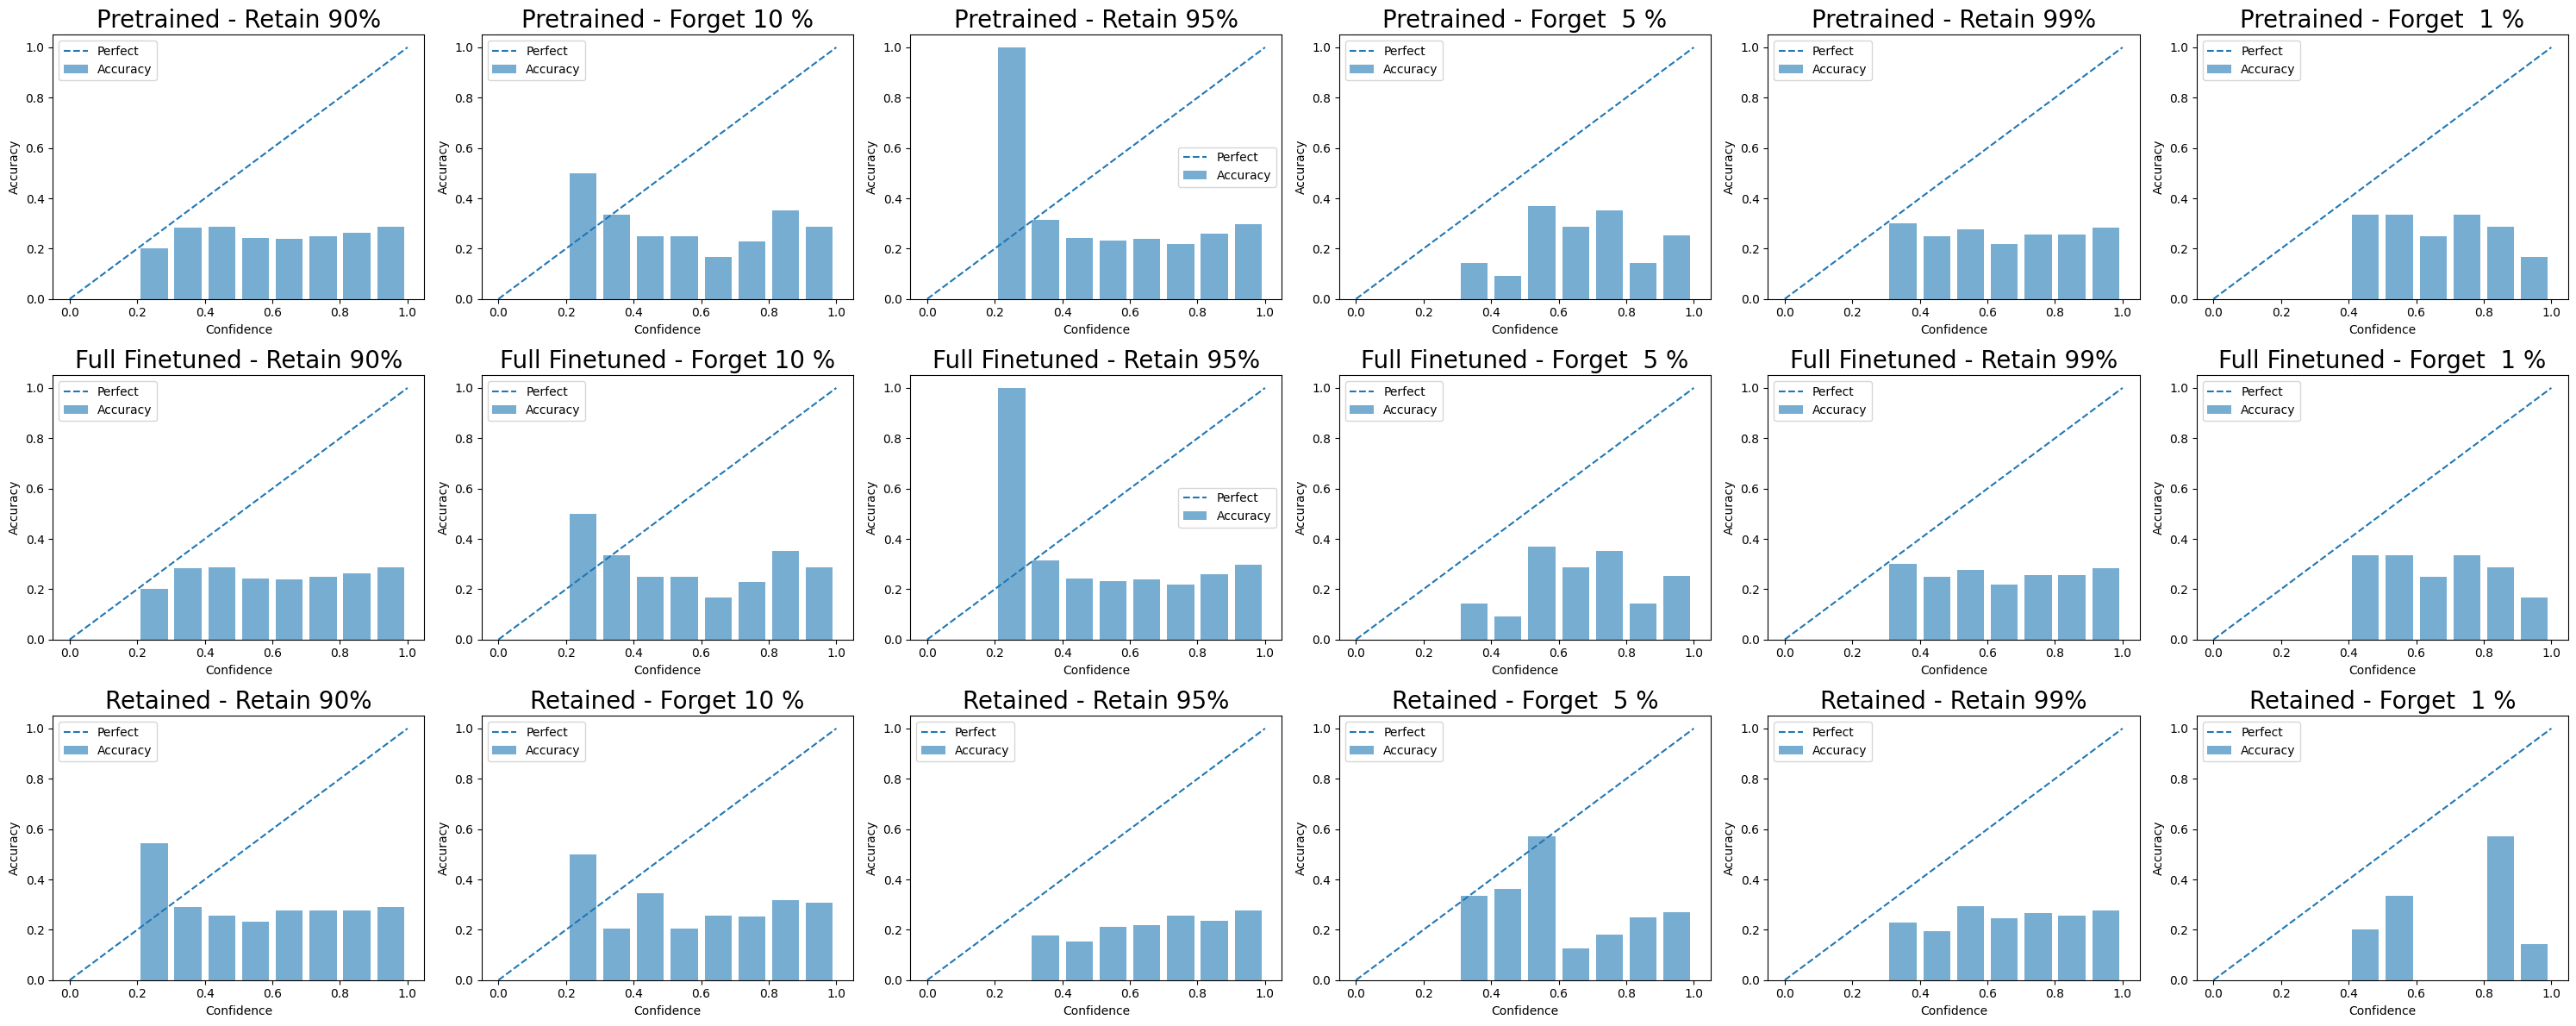

In [4]:
model_name = "Llama-3.2-1B-Instruct"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [
    ("old_llama_evals/relu_{model_name}_pretrained_retain90", "Pretrained 10%"),
    ("old_llama_evals/relu_{model_name}_pretrained_retain95", "Pretrained 5%"),
    ("old_llama_evals/relu_{model_name}_pretrained_retain99", "Pretrained 1%"),

    ("old_llama_evals/relu_{model_name}_full_retain90", "Full Finetuned 10%"),
    ("old_llama_evals/relu_{model_name}_full_retain95", "Full Finetuned 5%"),
    ("old_llama_evals/relu_{model_name}_full_retain99", "Full Finetuned 1%"),


    ("old_llama_evals/relu_{model_name}_retain90", "Retained 10%"),
    ("old_llama_evals/relu_{model_name}_retain95", "Retained 5%"),
    ("old_llama_evals/relu_{model_name}_retain99", "Retained 1%"),
]

nrows = 3
ncols = 6
plt.figure(figsize=(ncols*5, nrows*4))

results = []

for i, (task, task_name) in enumerate(tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name, subfig_nrows=3, subfig_ncols=6, subfig_pos=i*2+1)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e
    
plt.tight_layout()
df = pd.DataFrame(results)
# store all the results in a JSON file
with open(f"saves/eval/calibration_results-{model_name}-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)


## Llama 3.2 3B

=== ('old_llama_evals/relu_Llama-3.2-3B-Instruct_pretrained_retain90', 0) ===
--- Retain 90% ---
Accuracy: 0.26555555555555554
F1: 0.14609762849888297
Brier: 1.143560509118443
ECE: 0.5188114721576373
MCE: 0.7382622822826984
--- Forget 10 % ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.5106768918067291
MCE: 0.8245976030826568
=== ('old_llama_evals/relu_Llama-3.2-3B-Instruct_pretrained_retain95', 1) ===
--- Retain 95% ---
Accuracy: 0.26033166622795473
F1: 0.14194567759314078
Brier: 1.1517394225319888
ECE: 0.5245812726463259
MCE: 0.7208583869096887
--- Forget  5 % ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.540593034774065
MCE: 0.9925755858421326
=== ('old_llama_evals/relu_Llama-3.2-3B-Instruct_pretrained_retain99', 2) ===
--- Retain 99% ---
Accuracy: 0.2631977772164688
F1: 0.1407672819904934
Brier: 1.1491766240873176
ECE: 0.5213735392973501
MCE: 0.7102003566986692
--- Forget  1 % ---
Accuracy: 0.275
F1: 0.2315769

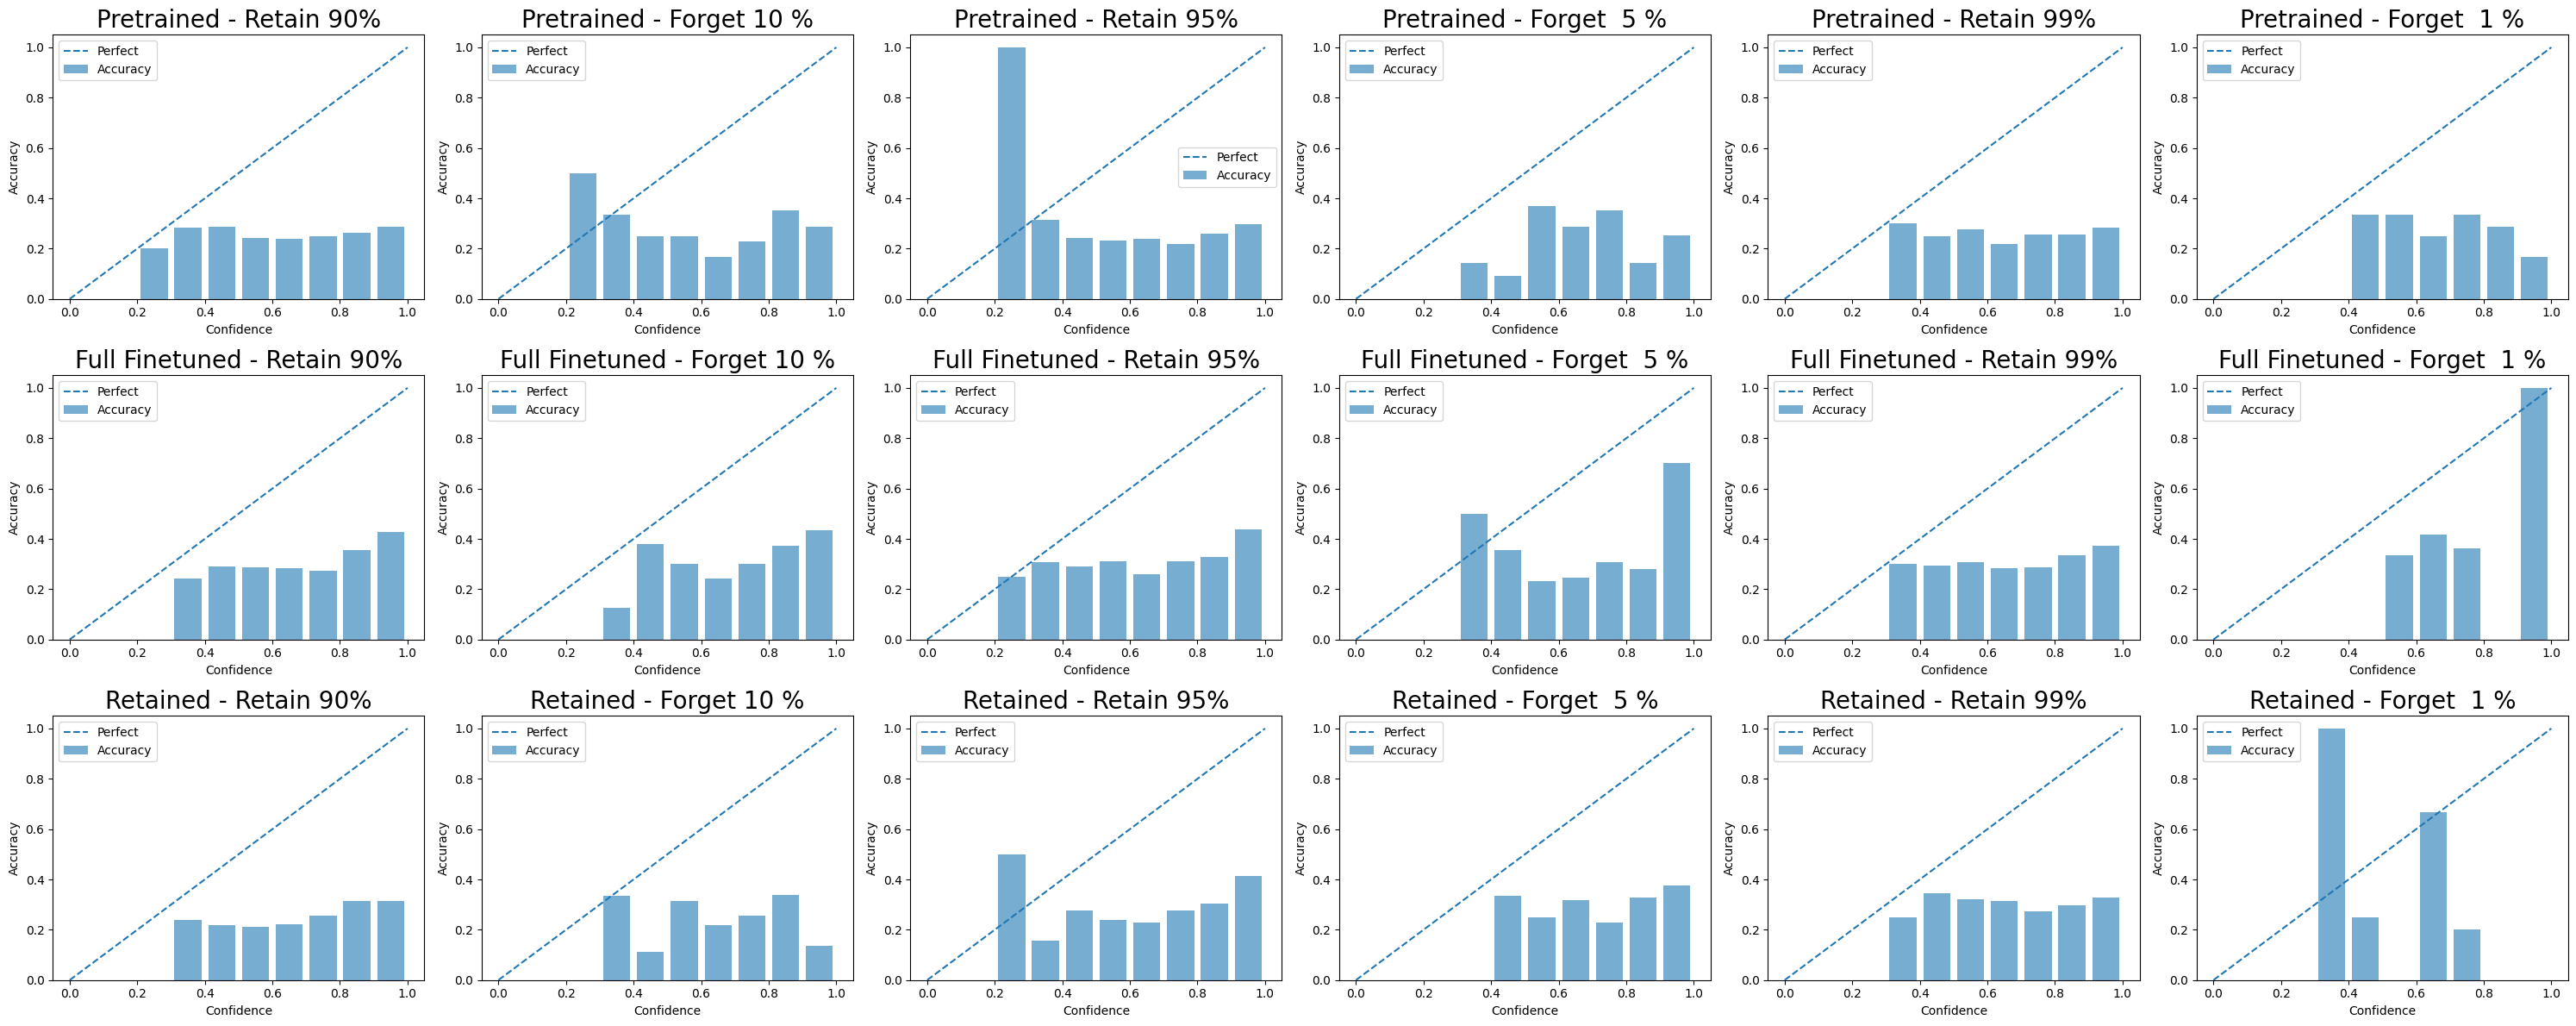

In [5]:
model_name = "Llama-3.2-3B-Instruct"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [
    ("old_llama_evals/relu_{model_name}_pretrained_retain90", "Pretrained 10%"),
    ("old_llama_evals/relu_{model_name}_pretrained_retain95", "Pretrained 5%"),
    ("old_llama_evals/relu_{model_name}_pretrained_retain99", "Pretrained 1%"),

    ("old_llama_evals/relu_{model_name}_full_retain90", "Full Finetuned 10%"),
    ("old_llama_evals/relu_{model_name}_full_retain95", "Full Finetuned 5%"),
    ("old_llama_evals/relu_{model_name}_full_retain99", "Full Finetuned 1%"),


    ("old_llama_evals/relu_{model_name}_retain90", "Retained 10%"),
    ("old_llama_evals/relu_{model_name}_retain95", "Retained 5%"),
    ("old_llama_evals/relu_{model_name}_retain99", "Retained 1%"),
]

nrows = 3
ncols = 6
plt.figure(figsize=(ncols*5, nrows*4))

results = []

for i, (task, task_name) in enumerate(tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name, subfig_nrows=3, subfig_ncols=6, subfig_pos=i*2+1)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e
    
plt.tight_layout()
df = pd.DataFrame(results)
# store all the results in a JSON file
with open(f"saves/eval/calibration_results-{model_name}-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)


## Llama 3 8B

=== ('old_llama_evals/relu_Llama-3.1-8B-Instruct_pretrained_retain90', 0) ===
--- Retain 90% ---
Accuracy: 0.26555555555555554
F1: 0.14609762849888297
Brier: 1.143560509118443
ECE: 0.5188114721576373
MCE: 0.7382622822826984
--- Forget 10 % ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.5106768918067291
MCE: 0.8245976030826568
=== ('old_llama_evals/relu_Llama-3.1-8B-Instruct_pretrained_retain95', 1) ===
--- Retain 95% ---
Accuracy: 0.26033166622795473
F1: 0.14194567759314078
Brier: 1.1517394225319888
ECE: 0.5245812726463259
MCE: 0.7208583869096887
--- Forget  5 % ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.540593034774065
MCE: 0.9925755858421326
=== ('old_llama_evals/relu_Llama-3.1-8B-Instruct_pretrained_retain99', 2) ===
--- Retain 99% ---
Accuracy: 0.2631977772164688
F1: 0.1407672819904934
Brier: 1.1491766240873176
ECE: 0.5213735392973501
MCE: 0.7102003566986692
--- Forget  1 % ---
Accuracy: 0.275
F1: 0.2315769

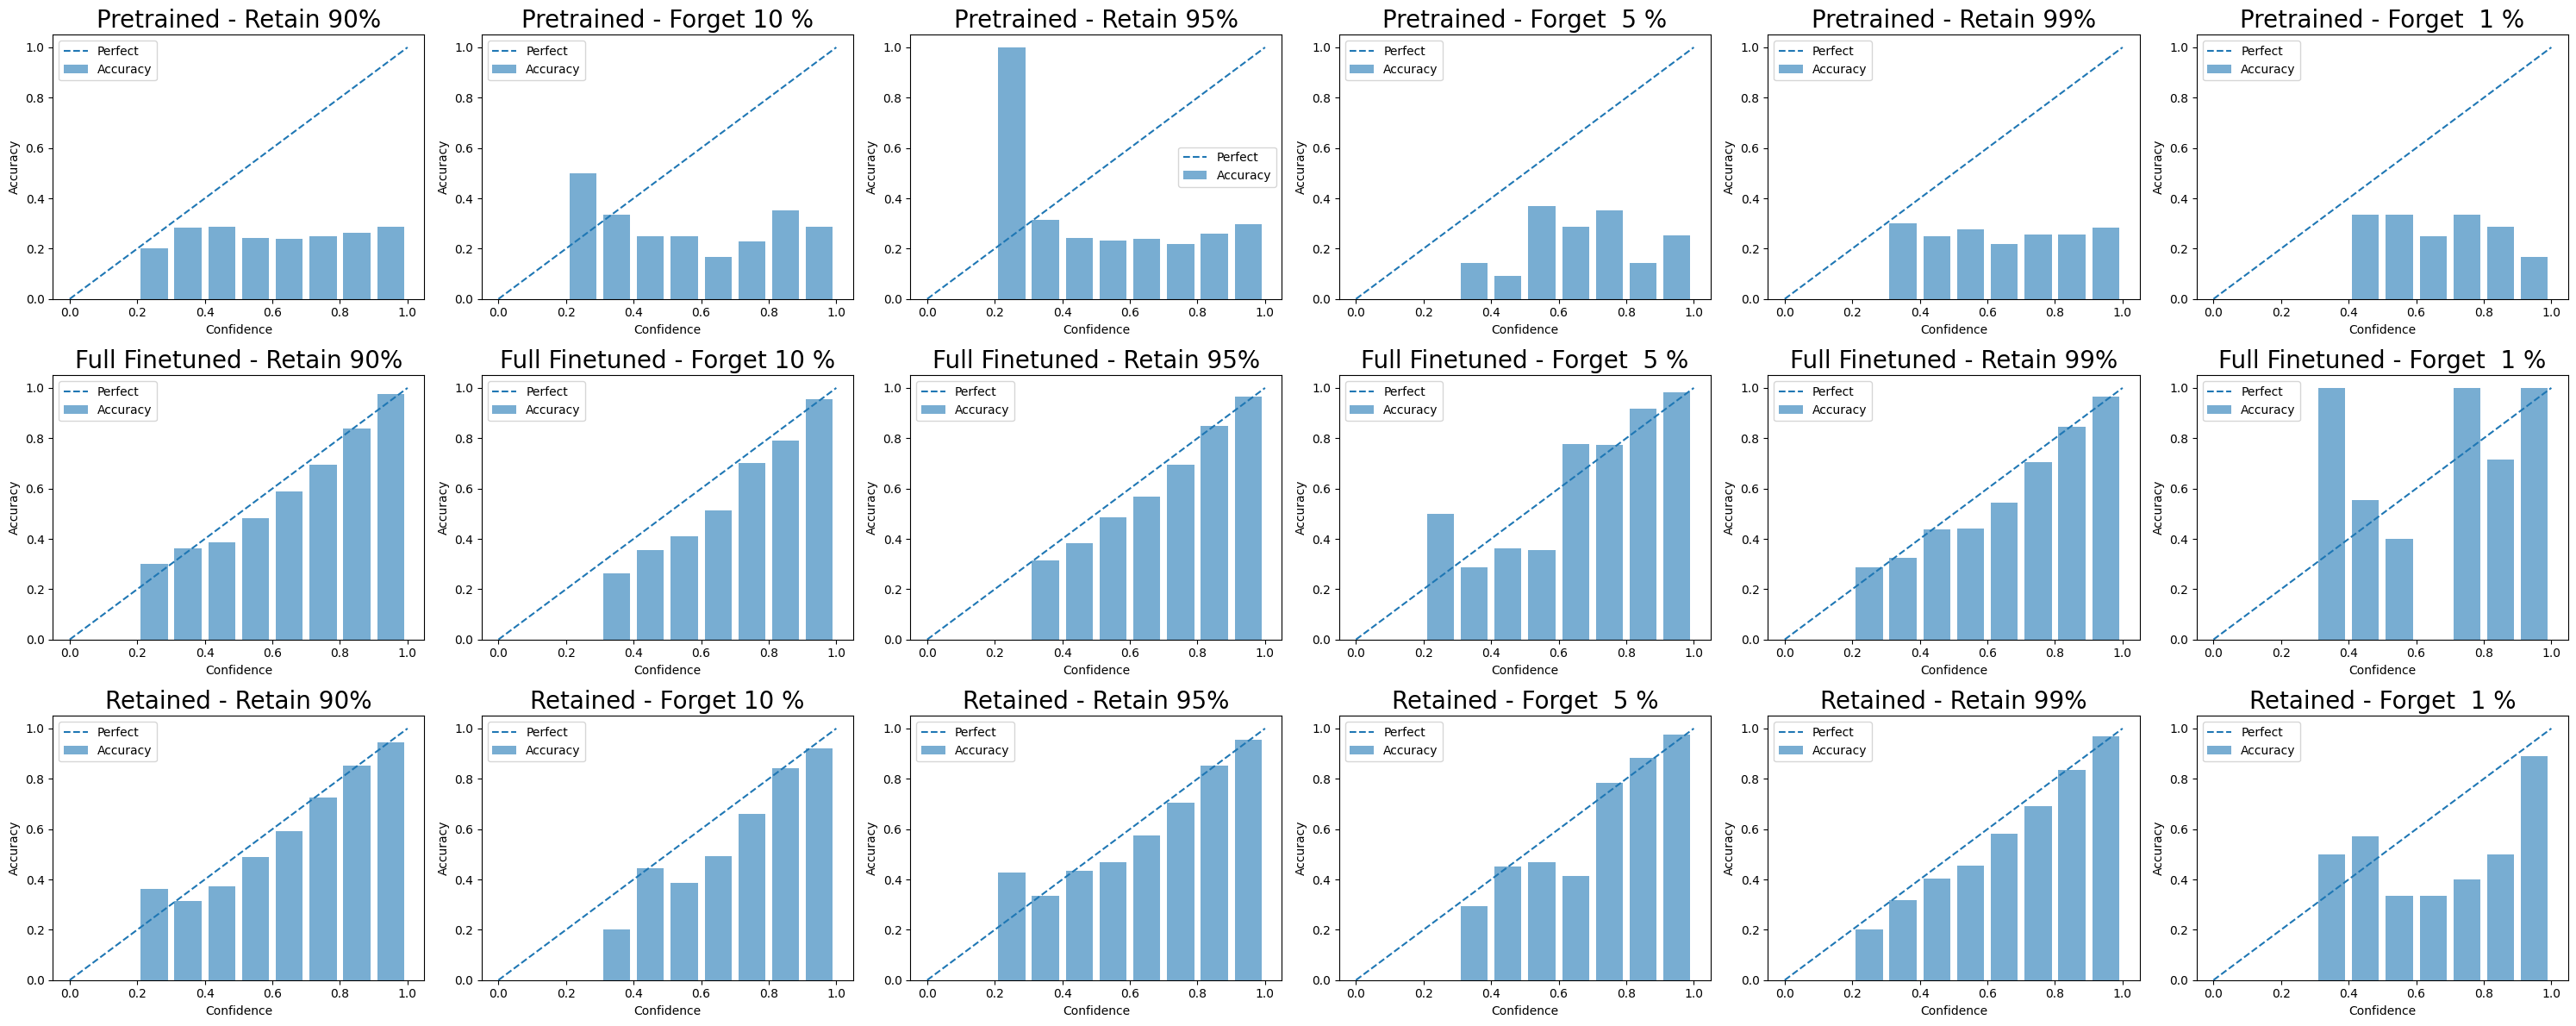

In [6]:
model_name = "Llama-3.1-8B-Instruct"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [
    ("old_llama_evals/relu_{model_name}_pretrained_retain90", "Pretrained 10%"),
    ("old_llama_evals/relu_{model_name}_pretrained_retain95", "Pretrained 5%"),
    ("old_llama_evals/relu_{model_name}_pretrained_retain99", "Pretrained 1%"),

    ("old_llama_evals/relu_{model_name}_full_retain90", "Full Finetuned 10%"),
    ("old_llama_evals/relu_{model_name}_full_retain95", "Full Finetuned 5%"),
    ("old_llama_evals/relu_{model_name}_full_retain99", "Full Finetuned 1%"),


    ("old_llama_evals/relu_{model_name}_retain90", "Retained 10%"),
    ("old_llama_evals/relu_{model_name}_retain95", "Retained 5%"),
    ("old_llama_evals/relu_{model_name}_retain99", "Retained 1%"),
]

nrows = 3
ncols = 6
plt.figure(figsize=(ncols*5, nrows*4))

results = []

for i, (task, task_name) in enumerate(tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name, subfig_nrows=3, subfig_ncols=6, subfig_pos=i*2+1)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e
    
plt.tight_layout()
df = pd.DataFrame(results)
# store all the results in a JSON file
with open(f"saves/eval/calibration_results-{model_name}-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)


# New Llama Reports

## Llama 3.2 1B

=== ('tofu_Llama-3.2-1B-Instruct_forget05_GradAscent/checkpoint-60', 0) ===
--- Retain 95% ---
Accuracy: 0.25401421426691234
F1: 0.10525637206238
Brier: 0.798298357304295
ECE: 0.14598795576263773
MCE: 0.17256615141575987
--- Forget  5 % ---
Accuracy: 0.25
F1: 0.1
Brier: 0.8184104677737924
ECE: 0.14670443221926688
MCE: 0.2345441285301657
=== ('tofu_Llama-3.2-1B-Instruct_forget05_GradDiff/checkpoint-60', 1) ===
--- Retain 95% ---
Accuracy: 0.39326138457488813
F1: 0.38585044947405583
Brier: 0.9469643638724586
ECE: 0.3949385211715011
MCE: 0.4889311688881391
--- Forget  5 % ---
Accuracy: 0.22
F1: 0.1766761814596784
Brier: 1.1460234947279133
ECE: 0.3887031039595604
MCE: 0.754032758779304
=== ('tofu_Llama-3.2-1B-Instruct_forget05_NPO/checkpoint-60', 2) ===
--- Retain 95% ---
Accuracy: 0.6428007370360621
F1: 0.6499003781269936
Brier: 0.5499920065434218
ECE: 0.19021281611765647
MCE: 0.2986334264278412
--- Forget  5 % ---
Accuracy: 0.61
F1: 0.602140440780025
Brier: 0.5894632636758361
ECE: 0.2183

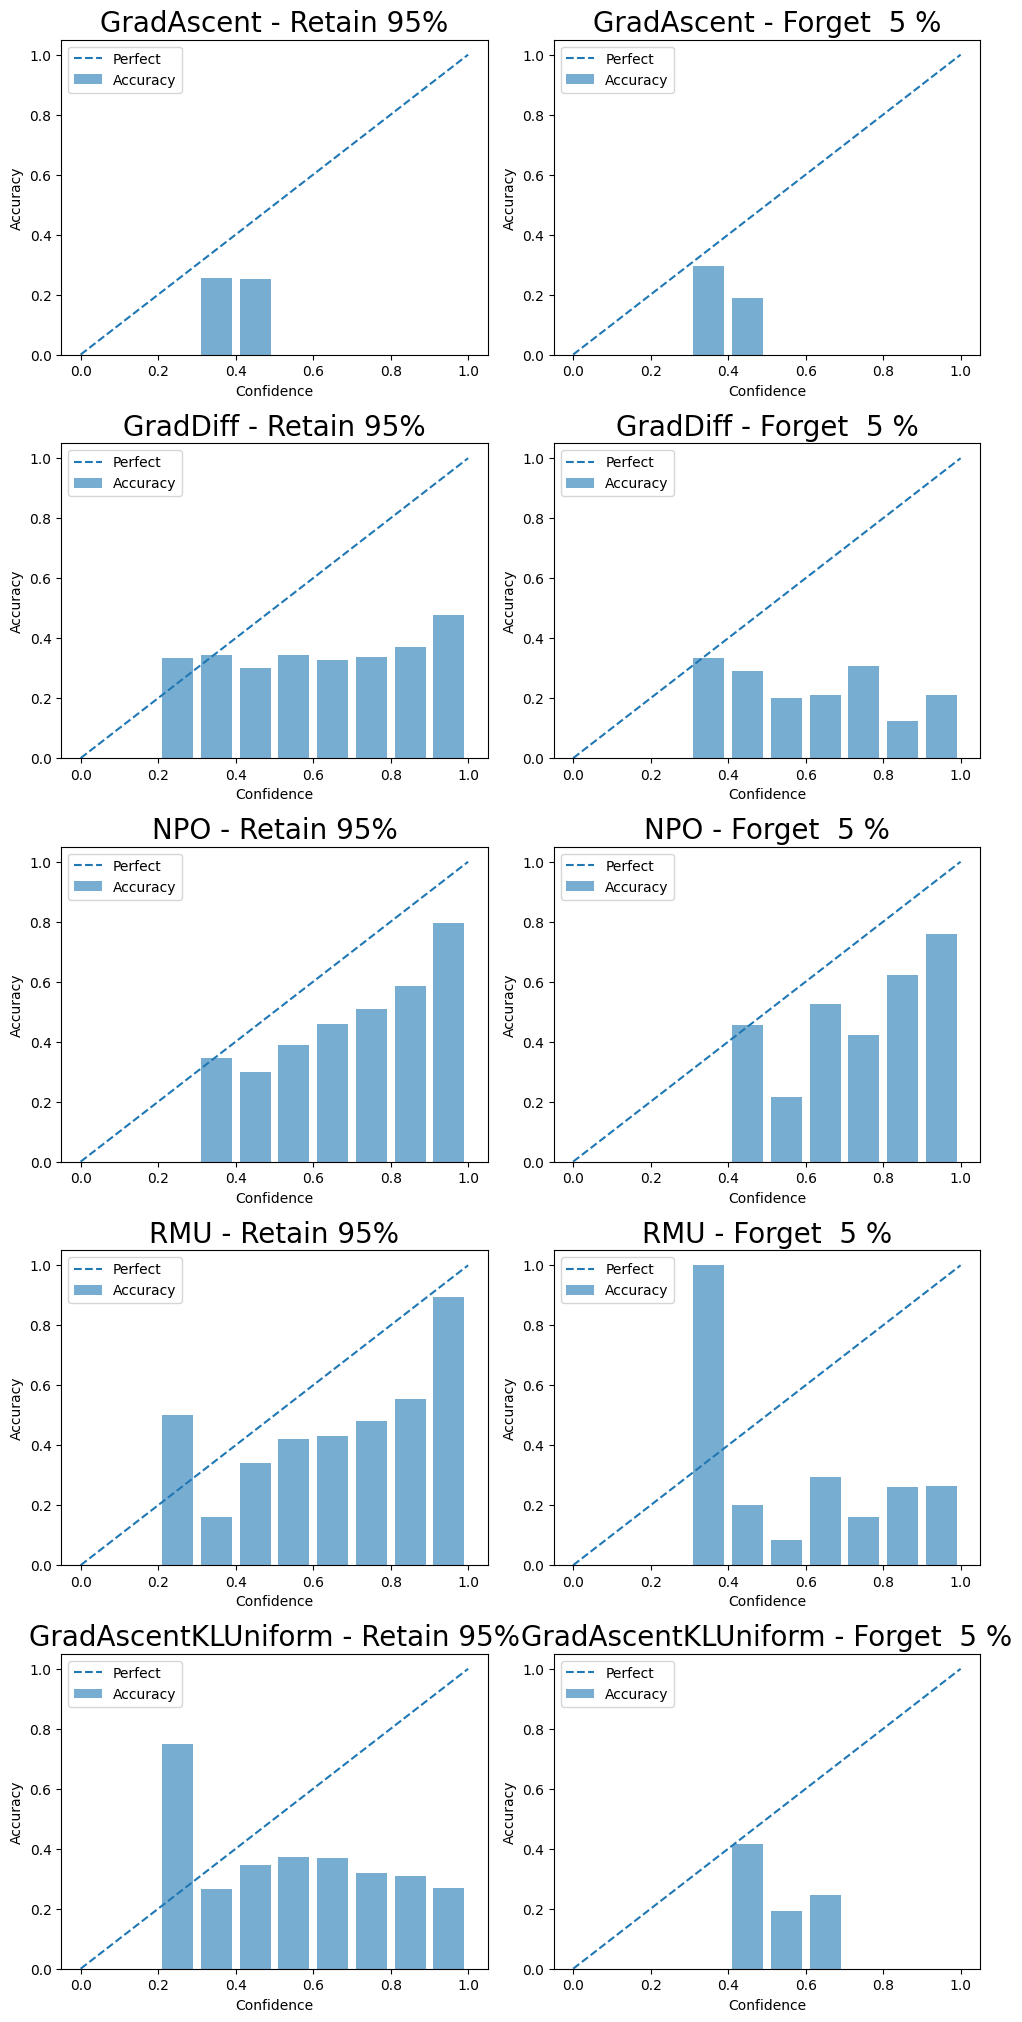

In [11]:
model_name = "Llama-3.2-1B-Instruct"
path_template = "saves/eval/{task_name}/TOFU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/evals/TOFU_EVAL.json"

tasks = [
    # ("relu_{model_name}_pretrained_retain90_nochat", "Pretrained 10%"),
    # ("tofu_{model_name}_pretrained_retain90_temp_4", "Pretrained 10%"),
    # ("relu_{model_name}_pretrained_retain95_nochat", "Pretrained 5%"),
    # ("tofu_{model_name}_pretrained_retain95_temp_4", "Pretrained 5%"),
    # ("relu_{model_name}_pretrained_retain99_nochat", "Pretrained 1%"),
    # ("tofu_{model_name}_pretrained_retain99_temp_1.3", "Pretrained 1%"),

    # ("relu_{model_name}_full_retain90_nochat", "Full Finetuned 10%"),
    # ("tofu_{model_name}_ft_retain90_temp_4", "Full Finetuned 10%"),
    # ("relu_{model_name}_full_retain95_nochat", "Full Finetuned 5%"),
    # ("tofu_{model_name}_ft_retain95_temp_4", "Full Finetuned 5%"),
    # ("relu_{model_name}_full_retain99_nochat", "Full Finetuned 1%"),
    # ("tofu_{model_name}_ft_retain99_temp_1.3", "Full Finetuned 1%"),

    # ("relu_{model_name}_retain90_nochat", "Retained 10%"),
    # ("tofu_{model_name}_retain90_temp_4", "Retained 10%"),
    # ("relu_{model_name}_retain95_nochat", "Retained 5%"),
    # ("tofu_{model_name}_retain95_temp_4", "Retained 5%"),
    # ("relu_{model_name}_retain99_nochat", "Retained 1%"),
    # ("tofu_{model_name}_retain99_temp_1.3", "Retained 1%"),
]

unlearn_tasks = [
    # ("tofu_{model_name}_forget01_GradAscent/checkpoint-10", "GradAscent 1%"),
    # ("tofu_{model_name}_forget01_GradDiff/checkpoint-10", "GradDiff 1%"),
    # ("tofu_{model_name}_forget01_NPO/checkpoint-10", "NPO 1%"),
    # ("tofu_{model_name}_forget01_RMU/checkpoint-10", "RMU 1%"),
    # ("tofu_{model_name}_forget01_GradAscentKLUniform/checkpoint-10", "GradAscentKLUniform 1%"),

    ("tofu_{model_name}_forget05_GradAscent/checkpoint-60", "GradAscent 5%"),
    ("tofu_{model_name}_forget05_GradDiff/checkpoint-60", "GradDiff 5%"),
    ("tofu_{model_name}_forget05_NPO/checkpoint-60", "NPO 5%"),
    ("tofu_{model_name}_forget05_RMU/checkpoint-60", "RMU 5%"),
    ("tofu_{model_name}_forget05_GradDiffKLUniform/checkpoint-60", "GradAscentKLUniform 5%"),
]

# Combine both lists, tagging each with its path template
all_tasks = (
    [(t, name, path_template) for t, name in tasks]
    + [(t, name, unlearn_path_template) for t, name in unlearn_tasks]
)

nrows = 8
ncols = 2
plt.figure(figsize=(ncols * 5, nrows * 4))

results = []

for i, (task, task_name, template) in enumerate(all_tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(
            template.format(task_name=task),
            title=task_name,
            subfig_nrows=nrows,
            subfig_ncols=ncols,
            subfig_pos=i * 2 + 1,
        )
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        # raise e

plt.tight_layout()
df = pd.DataFrame(results)
with open(f"saves/eval/calibration_results-{model_name}-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)
plt.savefig(
    f"saves/eval/plots/{model_name}_forgetall_reliability_diagram_unlearning.png",
    dpi=300,
    bbox_inches="tight",
)

## Llama 3.2 3B

=== ('tofu_Llama-3.2-3B-Instruct_forget10_GradAscent/checkpoint-60', 0) ===
--- Retain 90% ---
Accuracy: 0.25277777777777777
F1: 0.1008869179600887
Brier: 1.4944444444444445
ECE: 0.0
MCE: 0.0
--- Forget 10 % ---
Accuracy: 0.2556390977443609
F1: 0.10179640718562874
Brier: 1.4887218045112782
ECE: 0.0
MCE: 0.0
=== ('tofu_Llama-3.2-3B-Instruct_forget10_GradDiff/checkpoint-60', 1) ===
--- Retain 90% ---
Accuracy: 0.7680555555555556
F1: 0.7687359542518177
Brier: 0.3556943222786731
ECE: 0.1081645633859767
MCE: 0.23657338713344778
--- Forget 10 % ---
Accuracy: 0.2731829573934837
F1: 0.18348171688365145
Brier: 0.787551334895336
ECE: 0.07120601478077114
MCE: 0.9935555756092072
=== ('tofu_Llama-3.2-3B-Instruct_forget10_NPO/checkpoint-60', 2) ===
--- Retain 90% ---
Accuracy: 0.545
F1: 0.5441477364639633
Brier: 0.6041692379715246
ECE: 0.17752425874272984
MCE: 0.2897733350594838
--- Forget 10 % ---
Accuracy: 0.49874686716791977
F1: 0.4840389339749953
Brier: 0.6801270714917743
ECE: 0.2209623346203251

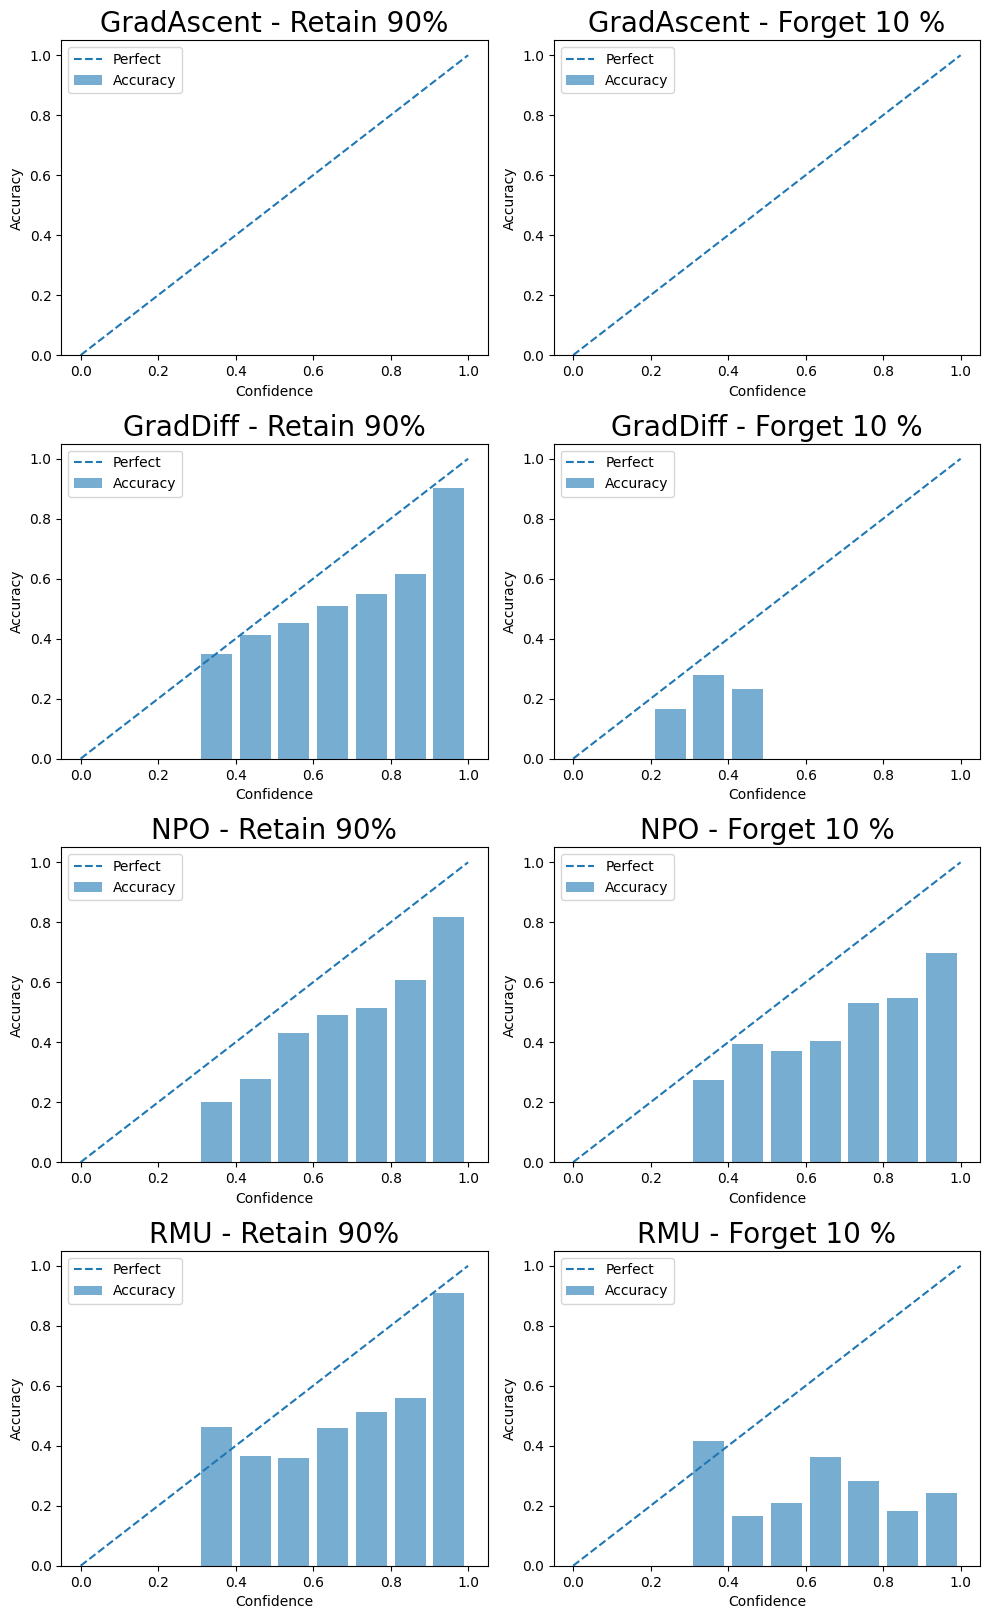

In [2]:
model_name = "Llama-3.2-3B-Instruct"
path_template = "saves/eval/{task_name}/TOFU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/evals/TOFU_EVAL.json"

tasks = [
    # ("relu_{model_name}_pretrained_retain90_nochat", "Pretrained 10%"),
    # ("tofu_{model_name}_pretrained_retain90_temp_4", "Pretrained 10%"),
    # ("relu_{model_name}_pretrained_retain95_nochat", "Pretrained 5%"),
    # ("tofu_{model_name}_pretrained_retain95_temp_4", "Pretrained 5%"),
    # ("relu_{model_name}_pretrained_retain99_nochat", "Pretrained 1%"),
    # ("tofu_{model_name}_pretrained_retain99_temp_1.3", "Pretrained 1%"),

    # ("relu_{model_name}_full_retain90_nochat", "Full Finetuned 10%"),
    # ("tofu_{model_name}_ft_retain90_temp_4", "Full Finetuned 10%"),
    # ("relu_{model_name}_full_retain95_nochat", "Full Finetuned 5%"),
    # ("tofu_{model_name}_ft_retain95_temp_4", "Full Finetuned 5%"),
    # ("relu_{model_name}_full_retain99_nochat", "Full Finetuned 1%"),
    # ("tofu_{model_name}_ft_retain99_temp_1.3", "Full Finetuned 1%"),

    # ("relu_{model_name}_retain90_nochat", "Retained 10%"),
    # ("tofu_{model_name}_retain90_temp_4", "Retained 10%"),
    # ("relu_{model_name}_retain95_nochat", "Retained 5%"),
    # ("tofu_{model_name}_retain95_temp_4", "Retained 5%"),
    # ("relu_{model_name}_retain99_nochat", "Retained 1%"),
    # ("tofu_{model_name}_retain99_temp_1.3", "Retained 1%"),
]

unlearn_tasks = [
    # ("tofu_{model_name}_forget01_GradAscent/checkpoint-5", "GradAscent 1%"),
    # ("tofu_{model_name}_forget01_GradDiff/checkpoint-5", "GradDiff 1%"),
    # ("tofu_{model_name}_forget01_NPO/checkpoint-5", "NPO 1%"),
    # ("tofu_{model_name}_forget01_RMU/checkpoint-5", "RMU 1%"),
    # ("tofu_{model_name}_forget01_GradAscentKLUniform/checkpoint-5", "GradAscentKLUniform 1%"),

    # ("tofu_{model_name}_forget05_GradAscent/checkpoint-30", "GradAscent 5%"),
    # ("tofu_{model_name}_forget05_GradDiff/checkpoint-30", "GradDiff 5%"),
    # ("tofu_{model_name}_forget05_NPO/checkpoint-30", "NPO 5%"),
    # ("tofu_{model_name}_forget05_RMU/checkpoint-30", "RMU 5%"),
    # # ("tofu_{model_name}_forget05_GradAscentKLUniform/checkpoint-5", "GradAscentKLUniform 1%"),

    ("tofu_{model_name}_forget10_GradAscent/checkpoint-60", "GradAscent 10%"),
    ("tofu_{model_name}_forget10_GradDiff/checkpoint-60", "GradDiff 10%"),
    ("tofu_{model_name}_forget10_NPO/checkpoint-60", "NPO 10%"),
    ("tofu_{model_name}_forget10_RMU/checkpoint-60", "RMU 10%"),
    # ("tofu_{model_name}_forget10_GradAscentKLUniform/checkpoint-5", "GradAscentKLUniform 1%"),
]

# Combine both lists, tagging each with its path template
all_tasks = (
    [(t, name, path_template) for t, name in tasks]
    + [(t, name, unlearn_path_template) for t, name in unlearn_tasks]
)

nrows = 8
ncols = 2
plt.figure(figsize=(ncols * 5, nrows * 4))

results = []

for i, (task, task_name, template) in enumerate(all_tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(
            template.format(task_name=task),
            title=task_name,
            subfig_nrows=nrows,
            subfig_ncols=ncols,
            subfig_pos=i * 2 + 1,
        )
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        # raise e

plt.tight_layout()
df = pd.DataFrame(results)
with open(f"saves/eval/calibration_results-{model_name}-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)
plt.savefig(
    f"saves/eval/plots/{model_name}_forgetall_reliability_diagram_unlearning.png",
    dpi=300,
    bbox_inches="tight",
)

## Llama 3.1 8B

=== ('relu_Llama-3.1-8B-Instruct_pretrained_retain90_nochat', 0) ===
--- Retain 90% ---
Accuracy: 0.7183333333333334
F1: 0.7194689921069646
Brier: 0.3664853974782818
ECE: 0.06019484831227198
MCE: 0.14098547594300626
--- Forget 10 % ---
Accuracy: 0.7268170426065163
F1: 0.7241532836106872
Brier: 0.35924519396317345
ECE: 0.05697567256769741
MCE: 0.2966017425060272
=== ('relu_Llama-3.1-8B-Instruct_pretrained_retain95_nochat', 1) ===
--- Retain 95% ---
Accuracy: 0.7175572519083969
F1: 0.7183116607207667
Brier: 0.3615503949729745
ECE: 0.060172150702374826
MCE: 0.13433900704750645
--- Forget  5 % ---
Accuracy: 0.66
F1: 0.6527257626094836
Brier: 0.4152526714132971
ECE: 0.11252669021487238
MCE: 0.43335562485914964
=== ('relu_Llama-3.1-8B-Instruct_pretrained_retain99_nochat', 2) ===
--- Retain 99% ---
Accuracy: 0.7183632230361202
F1: 0.7186028874544506
Brier: 0.3614227775398105
ECE: 0.057431837424812775
MCE: 0.15904193598291147
--- Forget  1 % ---
Accuracy: 0.7
F1: 0.6779396233057561
Brier: 0.36

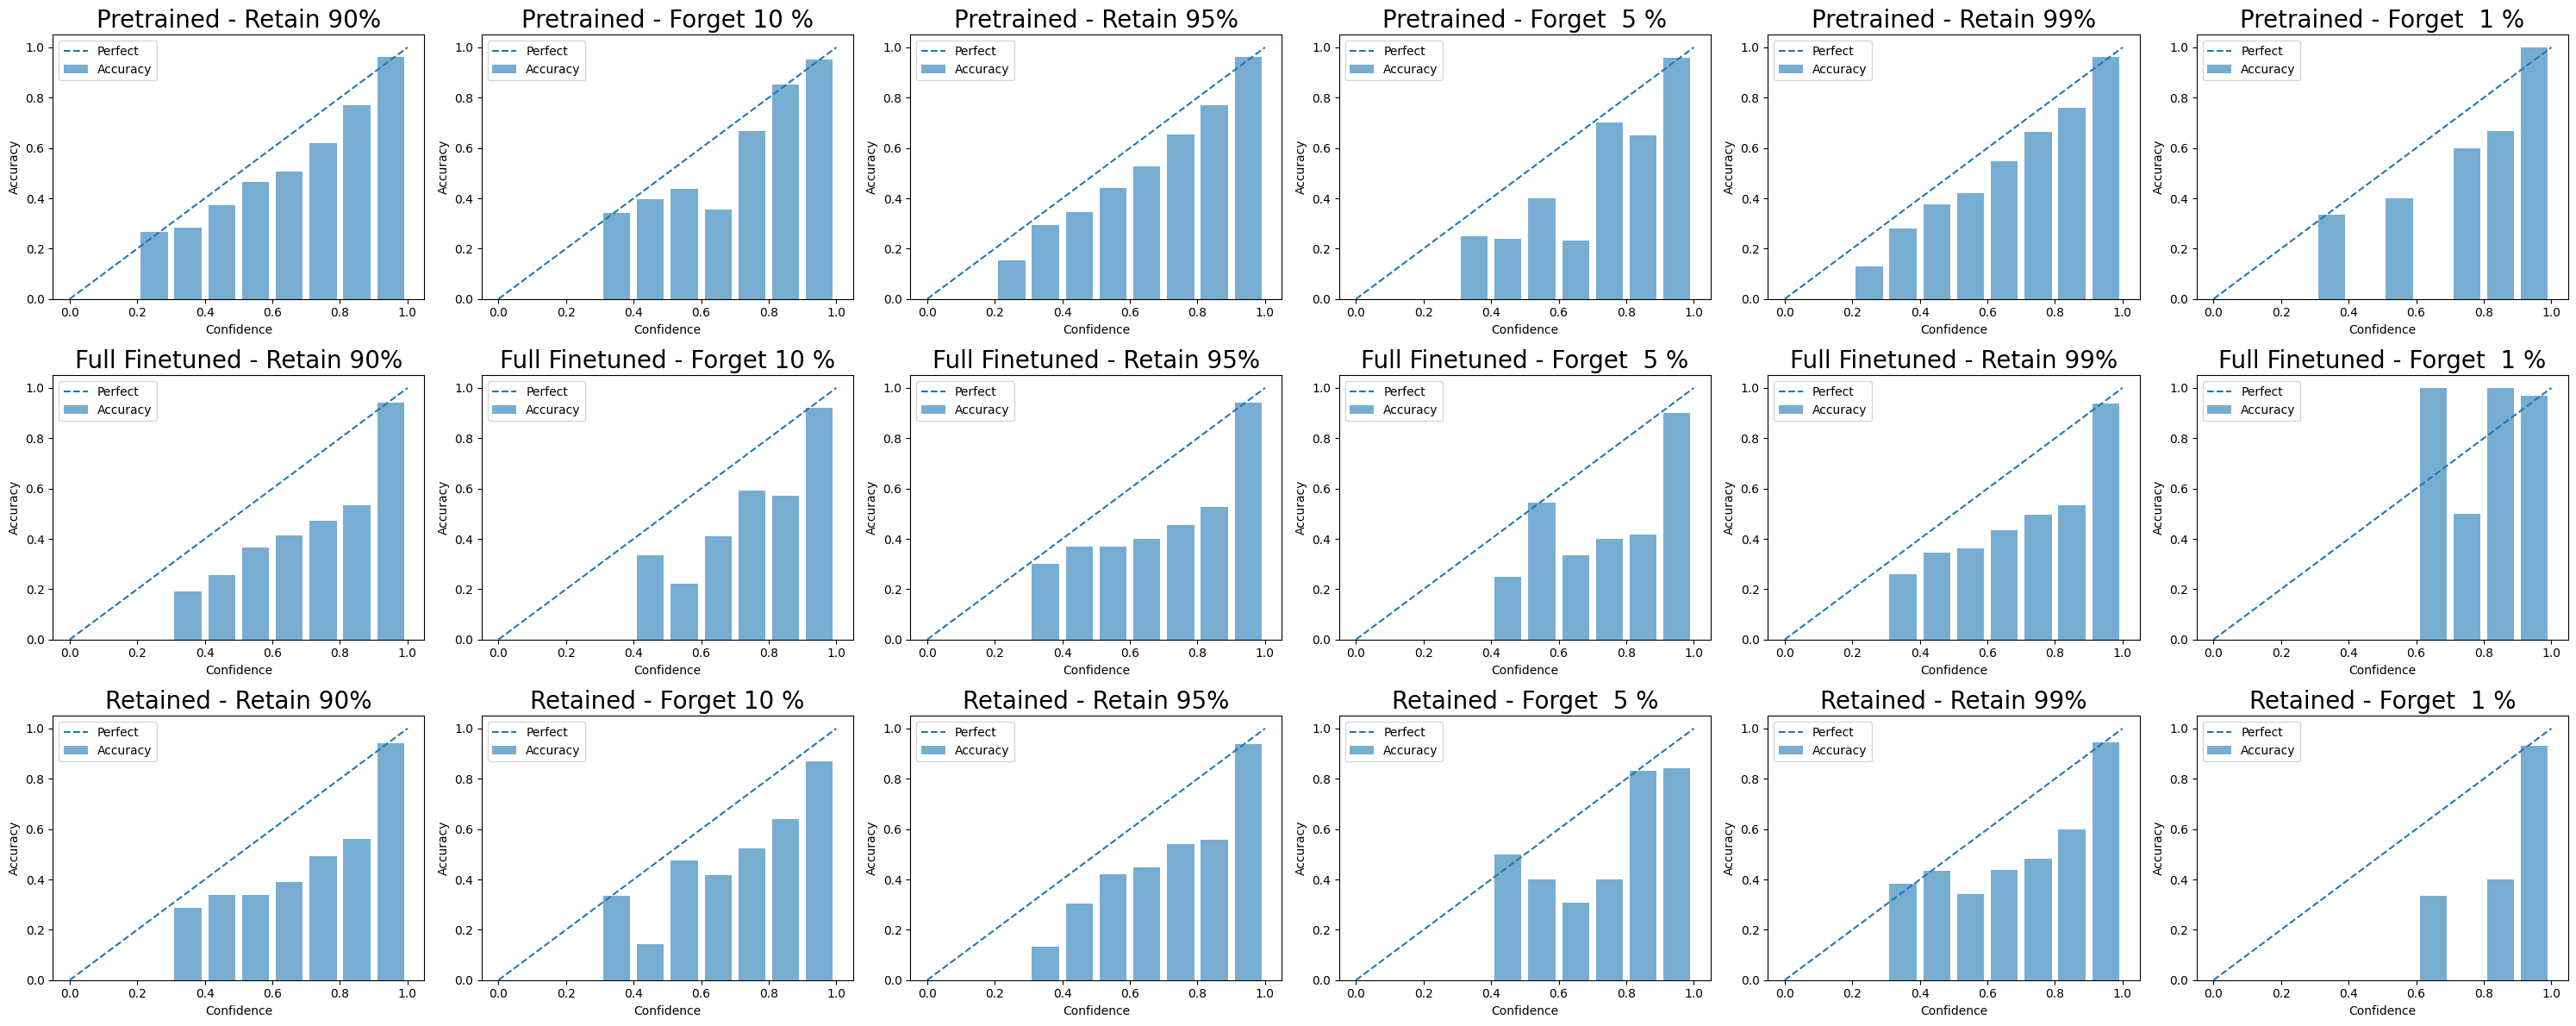

In [4]:
model_name = "Llama-3.1-8B-Instruct"
path_template = "saves/eval/{task_name}/RELU_EVAL.json"
unlearn_path_template = "saves/unlearn/{task_name}/{checkpoint}/evals/RELU_EVAL.json"
tasks = [
    ("relu_{model_name}_pretrained_retain90_nochat", "Pretrained 10%"),
    ("relu_{model_name}_pretrained_retain95_nochat", "Pretrained 5%"),
    ("relu_{model_name}_pretrained_retain99_nochat", "Pretrained 1%"),

    ("relu_{model_name}_full_retain90_nochat", "Full Finetuned 10%"),
    ("relu_{model_name}_full_retain95_nochat", "Full Finetuned 5%"),
    ("relu_{model_name}_full_retain99_nochat", "Full Finetuned 1%"),


    ("relu_{model_name}_retain90_nochat", "Retained 10%"),
    ("relu_{model_name}_retain95_nochat", "Retained 5%"),
    ("relu_{model_name}_retain99_nochat", "Retained 1%"),
]

nrows = 3
ncols = 6
plt.figure(figsize=(ncols*5, nrows*4))

results = []

for i, (task, task_name) in enumerate(tasks):
    task = task.format(model_name=model_name)
    try:
        print(f"=== {task, i} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task), title=task_name, subfig_nrows=3, subfig_ncols=6, subfig_pos=i*2+1)
        for m in metrics:
            results.append({"task": task, "checkpoint": 0, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        # raise e
    
plt.tight_layout()
df = pd.DataFrame(results)
# store all the results in a JSON file
with open(f"saves/eval/calibration_results-{model_name}-forgetall.json", "w") as f:
    json.dump(results, f, indent=4)

plt.savefig(f"saves/eval/plots/{model_name}_forgetall_reliability_diagram.png", dpi=300, bbox_inches="tight")

# Line plotting ECE and MCE

In [3]:
import os
from pathlib import Path
import pandas as pd
import json

model_name = "Llama-3.2-3B-Instruct"
splits = [
    ("retain90", "forget10"),
    ("retain95", "forget05"),
    ("retain99", "forget01")
]
temperatures = [0.3, 0.5, 0.7, 1.3, 2, 3, 4]
files = [
    ("saves/eval/tofu_{model_name}_{retain_split}_temp_{temperature}/TOFU_EVAL.json", "Retained"),
    ("saves/eval/tofu_{model_name}_pretrained_{retain_split}_temp_{temperature}/TOFU_EVAL.json", "Pretrained"),
    ("saves/eval/tofu_{model_name}_ft_{retain_split}_temp_{temperature}/TOFU_EVAL.json", "Full Finetuned"),
]

extracted_data = []

def get_values(data, key, split):
    try:
        return [value['score'] for value in data[key][split]['value_by_index'].values()]
    except KeyError:
        return []
    
def get_auc(data, key):
    try:
        return data[key]['auc']
    except KeyError:
        return None
    
def get_mcqa_probs(data, key):
    try:
        return [value['prob'] for value in data[key]['value_by_index'].values()]
    except KeyError:
        return [[]]
    
def get_mcqa_logits(data, key):
    try:
        return [value['logit'] for value in data[key]['value_by_index'].values()]
    except KeyError:
        return [[]]

def get_mcqa_labels(data, key):
    try:
        return [value['label'].strip() for value in data[key]['value_by_index'].values()]
    except KeyError:
        return []

def get_mcqa_generated_choice(data, key):
    try:
        return [value['generated choice'].strip() for value in data[key]['value_by_index'].values()]
    except KeyError:
        return []


for retain_split, forget_split in splits:
    for temperature in temperatures:
        for file, description in files:
            file = file.format(model_name=model_name, retain_split=retain_split, temperature=temperature)
            if not os.path.exists(file):
                print(f"File {file} does not exist. Skipping.")
                continue
            
            with open(file, 'r') as f:
                data = json.load(f)

            extracted_data.append({
                "model": model_name,
                "description": description,
                "retain_split": retain_split,
                "forget_split": forget_split,
                "temperature": temperature,

                # "mia_min_k_forget": get_values(data, 'mia_min_k', 'forget'),
                # "mia_min_k_holdout": get_values(data, 'mia_min_k', 'holdout'),
                # "mia_min_k_plus_plus_forget": get_values(data, 'mia_min_k_plus_plus', 'forget'),
                # "mia_min_k_plus_plus_holdout": get_values(data, 'mia_min_k_plus_plus', 'holdout'),
                # "mia_loss_forget": get_values(data, 'mia_loss', 'forget'),
                # "mia_loss_holdout": get_values(data, 'mia_loss', 'holdout'),
                # "mia_min_k_auc": get_auc(data, 'mia_min_k'),
                # "mia_min_k_plus_plus_auc": get_auc(data, 'mia_min_k_plus_plus'),
                # "mia_loss_auc": get_auc(data, 'mia_loss'),

                "mcqa_probs_forget": get_mcqa_probs(data, 'forget_mcqa_prob'),
                "mcqa_probs_retain": get_mcqa_probs(data, 'retain_mcqa_prob'),
                "mcqa_logits_forget": get_mcqa_logits(data, 'forget_mcqa_prob'),
                "mcqa_logits_retain": get_mcqa_logits(data, 'retain_mcqa_prob'),
                "mcqa_labels_forget": get_mcqa_labels(data, 'forget_mcqa_prob'),
                "mcqa_labels_retain": get_mcqa_labels(data, 'retain_mcqa_prob'),
                "mcqa_generated_choice_forget": get_mcqa_generated_choice(data, 'forget_mcqa_prob'),
                "mcqa_generated_choice_retain": get_mcqa_generated_choice(data, 'retain_mcqa_prob')
            })

df = pd.DataFrame(extracted_data)

# For each row in the dataframe, calculate the accuracy, F1, Brier score, ECE and MCE of the generated choices for the forget and retain splits, and add new columns
from sklearn.metrics import accuracy_score, f1_score
# Use the functions acc, f1 = compute_accuracy_f1(y_true, y_pred);  brier = compute_brier(y_true, probs); ece, mce = compute_ece_mce(y_true, probs, n_bins)

def calculate_metrics(labels, generated_choices, probs):
    if not labels or not generated_choices or not probs:
        return None, None, None, None, None
    
    acc = accuracy_score(labels, generated_choices)
    f1 = f1_score(labels, generated_choices, average='weighted')
    brier = compute_brier(labels, probs)
    ece, mce = compute_ece_mce(labels, probs, n_bins=10)
    
    return acc, f1, brier, ece, mce

df['forget_acc'] = None
df['forget_f1'] = None
df['forget_brier'] = None
df['forget_ece'] = None
df['forget_mce'] = None
df['retain_acc'] = None
df['retain_f1'] = None
df['retain_brier'] = None
df['retain_ece'] = None
df['retain_mce'] = None

for index, row in df.iterrows():
    forget_metrics = calculate_metrics(row['mcqa_labels_forget'], row['mcqa_generated_choice_forget'], row['mcqa_probs_forget'])
    retain_metrics = calculate_metrics(row['mcqa_labels_retain'], row['mcqa_generated_choice_retain'], row['mcqa_probs_retain'])
    
    df.at[index, 'forget_acc'] = forget_metrics[0]
    df.at[index, 'forget_f1'] = forget_metrics[1]
    df.at[index, 'forget_brier'] = forget_metrics[2]
    df.at[index, 'forget_ece'] = forget_metrics[3]
    df.at[index, 'forget_mce'] = forget_metrics[4]
    
    df.at[index, 'retain_acc'] = retain_metrics[0]
    df.at[index, 'retain_f1'] = retain_metrics[1]
    df.at[index, 'retain_brier'] = retain_metrics[2]
    df.at[index, 'retain_ece'] = retain_metrics[3]
    df.at[index, 'retain_mce'] = retain_metrics[4]

# display(df)

File saves/eval/tofu_Llama-3.2-3B-Instruct_pretrained_retain90_temp_0.3/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_pretrained_retain90_temp_0.5/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_pretrained_retain90_temp_0.7/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_0.3/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_pretrained_retain95_temp_0.3/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_0.5/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_pretrained_retain95_temp_0.5/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_0.7/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_pretrained_retain95_temp_0.7/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/

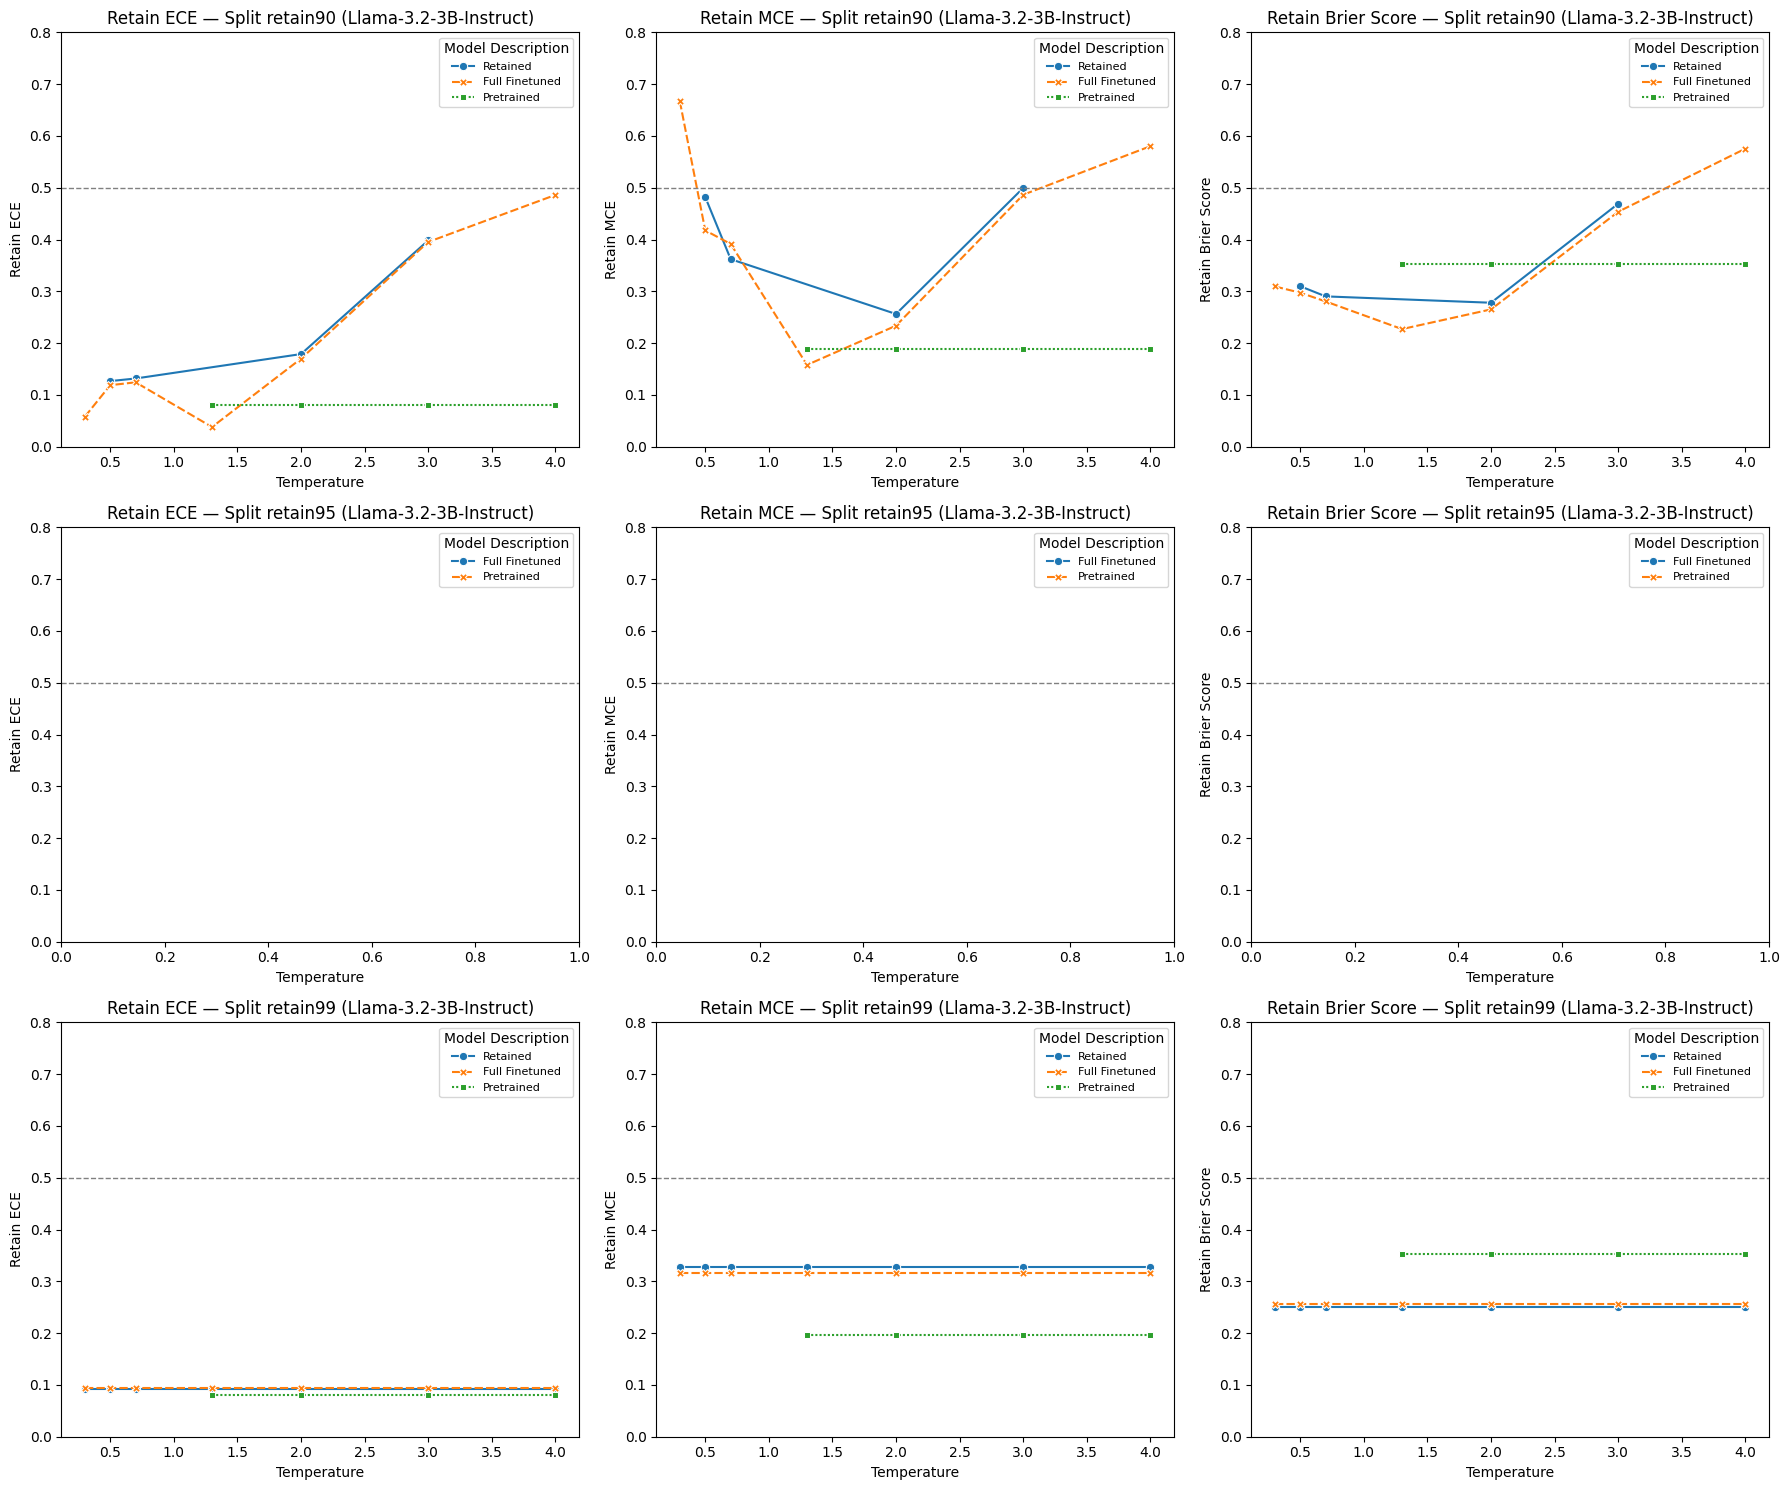

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
# Get unique retain splits to determine number of rows
retain_splits = sorted(df['retain_split'].unique())
n_rows = len(retain_splits)
metrics = ['ece', 'mce', 'brier']
titles = ['ECE', 'MCE', 'Brier Score']

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows), squeeze=False)

for row, split in enumerate(retain_splits):
    split_df = df[df['retain_split'] == split]
    for col, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[row, col]
        sns.lineplot(
            data=split_df,
            x='temperature',
            y=f'retain_{metric}',
            hue='description',
            style='description',
            markers=True,
            ax=ax,
        )
        ax.set_title(f'Retain {title} — Split {split} ({model_name})')
        ax.set_xlabel('Temperature')
        ax.set_ylabel(f'Retain {title}')
        ax.legend(title='Model Description', fontsize=8)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
        # if metric in ['ece', 'mce']:
        ax.set_ylim(0, 0.8)

plt.tight_layout()
# plt.savefig(f"saves/eval/plots/{model_name}_retain_metrics_across_temperatures.png", dpi=300, bbox_inches="tight")
plt.show()

The temperature values are constant across all temperatures, which is unexpected. This suggests that there might be an issue with how the temperature values are being extracted from the JSON files.
We have the actual logits and labels, so we can compute the ECE and MCE ourselves to verify the results.

    Lets first verify that the logits across all temperatures are different, which would suggest that the temperature values are not being extracted correctly. If the logits are different, then we can compute the ECE and MCE ourselves to verify the results.

In [31]:
# Check if the logits are the same across temperatures for the same description and retain_split. If they are same, print a warning message.
for description in df['description'].unique():
    for retain_split in df['retain_split'].unique():
        subset = df[(df['description'] == description) & (df['retain_split'] == retain_split)]
        if subset.empty:
            continue

        retain_logits_sets = subset['mcqa_logits_retain'].dropna().map(lambda x: repr(x)).unique()
        forget_logits_sets = subset['mcqa_logits_forget'].dropna().map(lambda x: repr(x)).unique()
        if (
            len(retain_logits_sets) == 1
            and len(forget_logits_sets) == 1
            and len(subset['temperature'].unique()) > 1
        ):
            print(f"Warning: Both retain and forget logits are identical across temperatures for description '{description}' and retain split '{retain_split}'")